# Step 0 : Importing the modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [2]:
# Reading the csv file
df = pd.read_csv("E:/Cranfield_BDA/PA/assignment/Group_Assignment/atp_tennis.csv")

In [3]:
df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4


# Step 1 : Initial Inspection 

In [4]:
# 1. Basic shape of dataset
print("Shape of dataset:", df.shape)

# 5. Data types
print("\nData types:")
print(df.dtypes)

# 6. General dataset info
print("\nDataset info:")
df.info()

# 7. Summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(df.describe())

# 8. Summary statistics for categorical columns
print("\nSummary statistics for categorical columns:")
display(df.describe(include='object'))

# 9. Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# 10. Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Shape of dataset: (65884, 17)

Data types:
Tournament     object
Date           object
Series         object
Court          object
Surface        object
Round          object
Best of         int64
Player_1       object
Player_2       object
Winner         object
Rank_1          int64
Rank_2          int64
Pts_1           int64
Pts_2           int64
Odd_1         float64
Odd_2         float64
Score          object
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65884 entries, 0 to 65883
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  65884 non-null  object 
 1   Date        65884 non-null  object 
 2   Series      65884 non-null  object 
 3   Court       65884 non-null  object 
 4   Surface     65884 non-null  object 
 5   Round       65884 non-null  object 
 6   Best of     65884 non-null  int64  
 7   Player_1    65884 non-null  object 
 8   Player_2    65884 non-null  ob

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000
mean,3.378392,75.888835,75.614428,1126.829625,1131.573812,2.410349,2.409366
std,0.783335,100.607793,101.040522,1715.540143,1738.245472,2.653615,2.641955
min,3.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.000000,24.000000,25.000000,98.000000,99.000000,1.333000,1.333000
50%,3.000000,53.000000,54.000000,696.000000,696.000000,1.730000,1.800000
75%,3.000000,92.000000,92.000000,1240.000000,1245.000000,2.750000,2.750000
max,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000,51.000000



Summary statistics for categorical columns:


,Tournament,Date,Series,Court,Surface,Round,Player_1,Player_2,Winner,Score
count,65884,65884,65884,65884,65884,65884,65884,65884,65884,65884
unique,266,6415,8,2,4,8,1499,1496,1162,7068
top,French Open,2001-01-15,ATP250,Outdoor,Hard,1st Round,Federer R.,Federer R.,Federer R.,6-3 6-4
freq,3172,125,17463,54230,35419,30197,668,725,1151,1200



Missing values in each column:
Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64

Number of duplicate rows: 0


### Initial Data Inspection Insights

1. The dataset contains 65,884 tennis matches, which is sufficiently large for building reliable machine learning models.

2. The average values of `Rank_1` and `Rank_2` are very similar, and the same pattern is seen for `Pts_1`, `Pts_2`, `Odd_1`, and `Odd_2`. This suggests that Player 1 and Player 2 were assigned randomly rather than always placing the stronger player in one position.

3. Several numerical columns contain `-1` as the minimum value, including rankings, ATP points, and betting odds. Since these values cannot realistically be negative, `-1` is likely being used as a placeholder for missing values and should later be converted to NaN.

4. Most matches are best-of-3 sets because the median and most common value of the `Best of` column is 3. Only a smaller number of matches are best-of-5 sets, which are likely Grand Slam matches.

5. Rankings show large variation across players. Although most players are ranked within the top 100, some rankings go above 3000 and even 4000, indicating that qualifiers and lower-ranked players are also included in the dataset.

6. ATP points also vary widely. The maximum ATP points exceed 16,000, which is realistic for top-ranked players during peak periods.

7. Betting odds are heavily right-skewed. Most odds are between 1.3 and 2.8, but some matches have extremely high odds above 50, indicating matches with very strong favorites and very weak underdogs.

8. The dataset contains 266 unique tournaments, 8 tournament series types, 4 court surfaces, and 8 match rounds. This provides a good mix of contextual information for modelling.

9. Player names have very high cardinality, with around 1,500 unique player names. Directly using player names in modelling may create too many features, so ranking, ATP points, and player-based difference features may be more useful.

10. Hard court is the most common playing surface, which is expected because many ATP tournaments are played on hard courts.

11. Outdoor matches are much more common than indoor matches.

12. The most frequent round is the first round, indicating that the dataset contains many early-stage tournament matches.

13. The most common tournament is the French Open, suggesting that Grand Slam tournaments contribute a large share of the dataset.

14. The `Score` column should not be used as a predictor because the final score is only known after the match has been completed, which would create data leakage.

## Unique Values Check

In [5]:
#unique values check
for column in df.columns:
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print("-" * 40)

Unique values in 'Tournament':
['Australian Hardcourt Championships' 'Gold Flake Open' 'Qatar Open'
 'Heineken Open' 'Sydney International' 'Australian Open' 'Dubai Open'
 'Marseille Open' 'Sybase Open' 'Kroger St. Jude'
 'ABN AMRO World Tennis Tournament' 'AXA Cup' 'Mexican Open'
 'Copenhagen Open' 'Citrix Tennis Championships' 'Chevrolet Cup'
 'Colombia Open' 'Franklin Templeton Tennis Classic' 'Indian Wells TMS'
 'Ericsson Open' 'Galleryfurniture.com Tennis Challenge'
 'Grand Prix Hassan II' 'Estoril Open' 'Monte Carlo Masters'
 'Open Seat Godo' 'Mallorca Open' 'BMW Open'
 'U.S. Clay Court Championships' 'Rome TMS' 'Hamburg TMS'
 'Internationaler Raiffeisen Grand Prix' 'French Open' 'Gerry Weber Open'
 'Stella Artois' 'Nottingham Open' 'Heineken Trophy' 'Wimbledon'
 'Swedish Open' 'Gstaad Open' 'Hall of Fame Championships' 'Dutch Open'
 'Mercedes Cup' 'Croatia Open' 'Generali Open' 'Mercedes-Benz Cup'
 "Tennis Int'l of San Marino" 'Toronto TMS' 'Cincinnati TMS'
 'RCA Championships' 

As we can see there are -1 value in Pts_1, pts_2, odd_1, odd_2 columns. Mostly they are missing values and we have to deal with these

 Columns classification

Numerical Columns :
['Best of', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']

Categorical Columns :
['Tournament', 'Series', 'Court', 'Surface', 'Round', 'Player_1', 'Player_2', 'Score']

Date type : ['Date']

Target Variable : ['Winner']

### Replacing -1 and 0 from the columns

In [6]:
# Replace -1 with NaN in selected columns

cols_to_replace = ['Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Rank_1', 'Rank_2']

for col in cols_to_replace:
    df[col] = df[col].replace(-1, np.nan)
    
# Replace 0 with NaN in betting odds columns
odds_cols = ['Odd_1', 'Odd_2']

for col in odds_cols:
    df[col] = df[col].replace(0, np.nan)

In [7]:
df.count()

Tournament    65884
Date          65884
Series        65884
Court         65884
Surface       65884
Round         65884
Best of       65884
Player_1      65884
Player_2      65884
Winner        65884
Rank_1        65870
Rank_2        65872
Pts_1         50232
Pts_2         50231
Odd_1         62101
Odd_2         62103
Score         65884
dtype: int64

# Step 2 : Missing Values Detection

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(
    by='Missing Percentage', ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Pts_2,15653,23.758424
Pts_1,15652,23.756906
Odd_1,3783,5.741910
Odd_2,3781,5.738874
Rank_1,14,0.021249
Rank_2,12,0.018214


### Missing Value Insights

1. `Pts_1` and `Pts_2` have around 23.8% missing values, which is quite high.

2. Since ATP points are important predictors of player strength, these columns should not be removed.

3. Median imputation is suitable for `Pts_1` and `Pts_2` because ATP points are highly skewed and contain extreme values.

4. `Odd_1` and `Odd_2` have around 5.7% missing values, which is relatively small.

5. Betting odds are also very important predictors because they reflect bookmaker expectations of the match outcome.

6. Median imputation is also appropriate for `Odd_1` and `Odd_2` because betting odds are right-skewed and contain extreme values.

7. Since the missing percentages are not extremely high, keeping these columns and imputing them is better than dropping them.

# Step 3 : Target Variable Creation

In [9]:
# =========================================================
# TARGET VARIABLE CREATION
# =========================================================

# Create binary target variable
# 1 = Player_1 wins
# 0 = Player_2 wins
df['target'] = np.where(df['Winner'] == df['Player_1'], 1, 0)

# Check target distribution
print(df['target'].value_counts())

# Check target percentage distribution
print(df['target'].value_counts(normalize=True) * 100)
# Drop leakage columns after target creation

df = df.drop(columns=['Winner', 'Score'])

target
1    32942
0    32942
Name: count, dtype: int64
target
1    50.0
0    50.0
Name: proportion, dtype: float64


### Target Variable Insights

1. The target variable is perfectly balanced.

2. There are 32,942 matches where Player 1 won and 32,942 matches where Player 2 won.

3. Both classes represent exactly 50% of the dataset.

4. Since the target variable is balanced, there is no need for class balancing techniques such as SMOTE, undersampling, or class weights.

5. This is beneficial because the models will not be biased toward one class.

6. Accuracy, Precision, Recall, F1-Score, and ROC-AUC can all be used safely for model evaluation because the target classes are evenly distributed.

# Step 4 : Exploratory Data Analysis


Numerical Columns = ['Best of', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']

categorical Columns = ['Series', 'Court', 'Surface', 'Round']

Target Column = ['target']

In [10]:
# Defining the numerical, categorical and target variables
target = "target"
num_cols = ["Best of","Rank_1","Rank_2","Pts_1","Pts_2","Odd_1","Odd_2"]
cat_cols = ["Tournament","Series","Court","Surface","Round","Player_1","Player_2"]
date_cols = ["Date"]

## 4.1 Univariate Analysis

### 4.1.1 target Variable

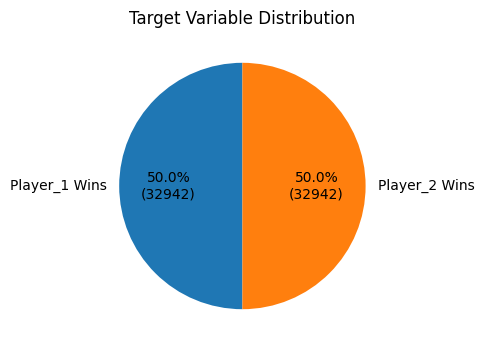

In [11]:
# =========================================================
# PIE CHART OF TARGET VARIABLE WITH COUNT AND PERCENTAGE
# =========================================================

target_counts = df[target].value_counts()

labels = [
    f'Player_1 Wins',
    f'Player_2 Wins'
]

plt.figure(figsize=(4,4))

plt.pie(
    target_counts,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100 * target_counts.sum()))})',
    startangle=90
)

plt.title('Target Variable Distribution')
plt.show()

Insights from Target Variable Distribution

1. The target variable is perfectly balanced, with both classes representing exactly 50% of the dataset.

2. There are 32,942 matches where Player 1 won and 32,942 matches where Player 2 won.

3. Since both classes are equally distributed, the dataset does not suffer from class imbalance.

4. There is no need to apply techniques such as SMOTE, undersampling, oversampling, or class weights.

5. A balanced target variable is beneficial because machine learning models will not become biased toward one class.

6. Evaluation metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix can all be used reliably.

### 4.1.2 Numerical Variables

========================================================Univariate Analysis of Numerical Variables===========================================


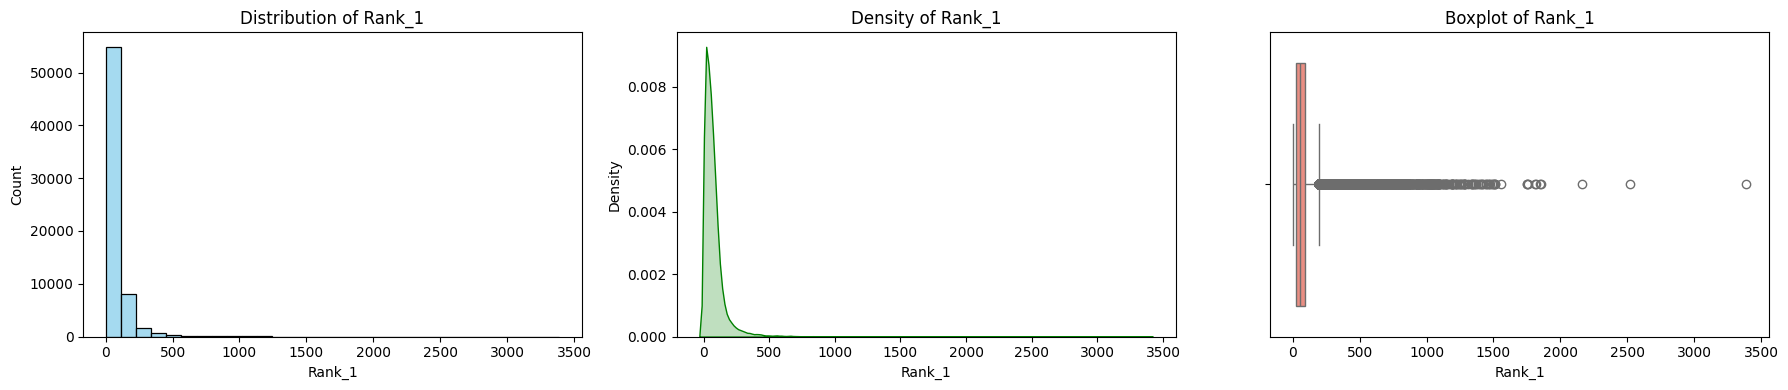

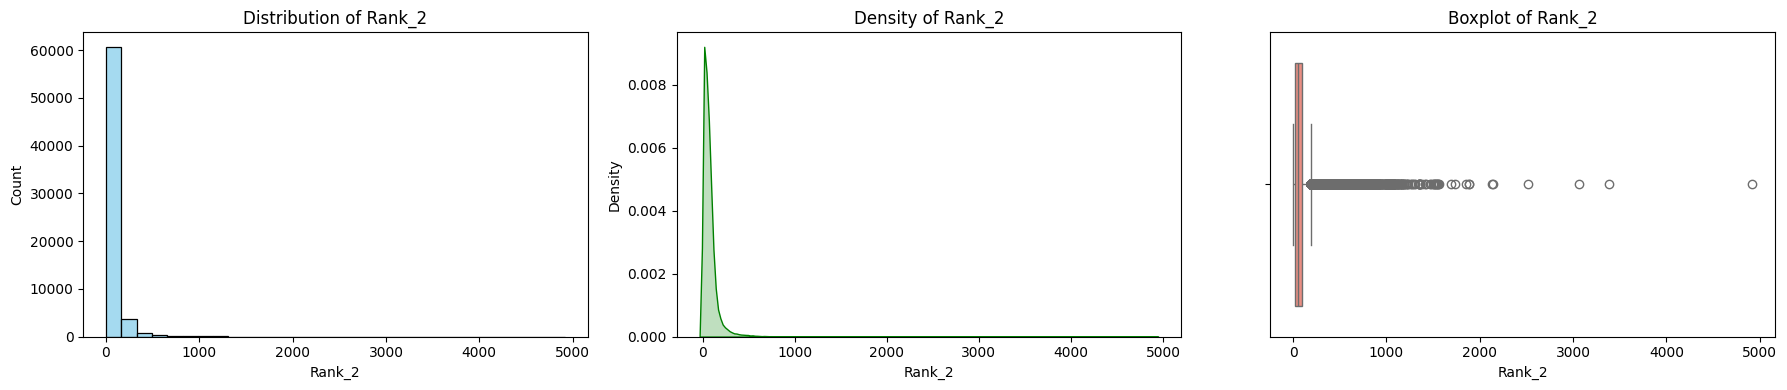

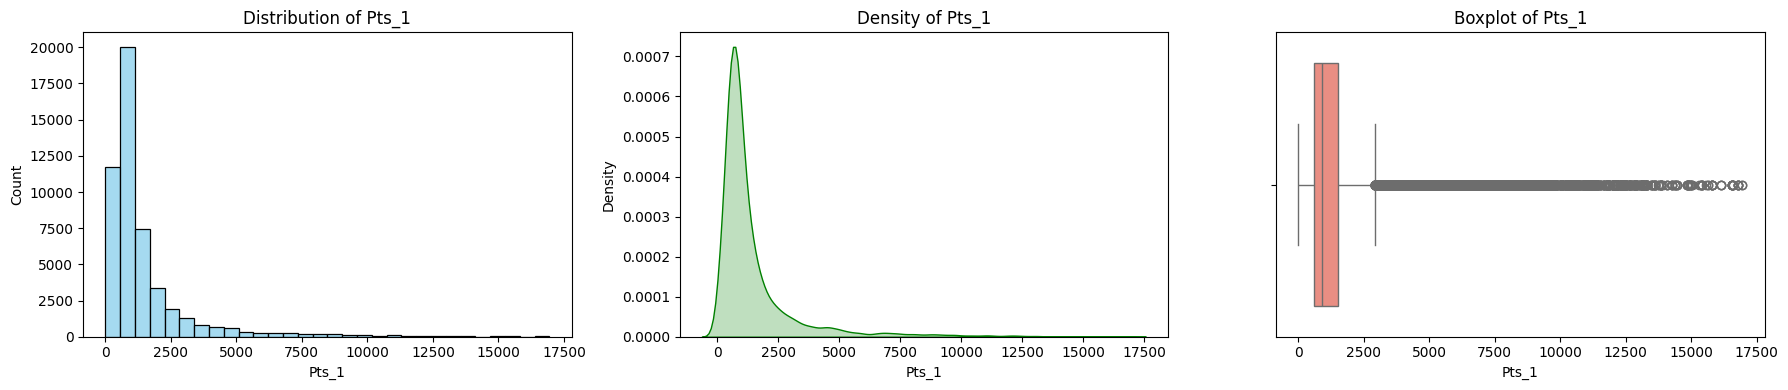

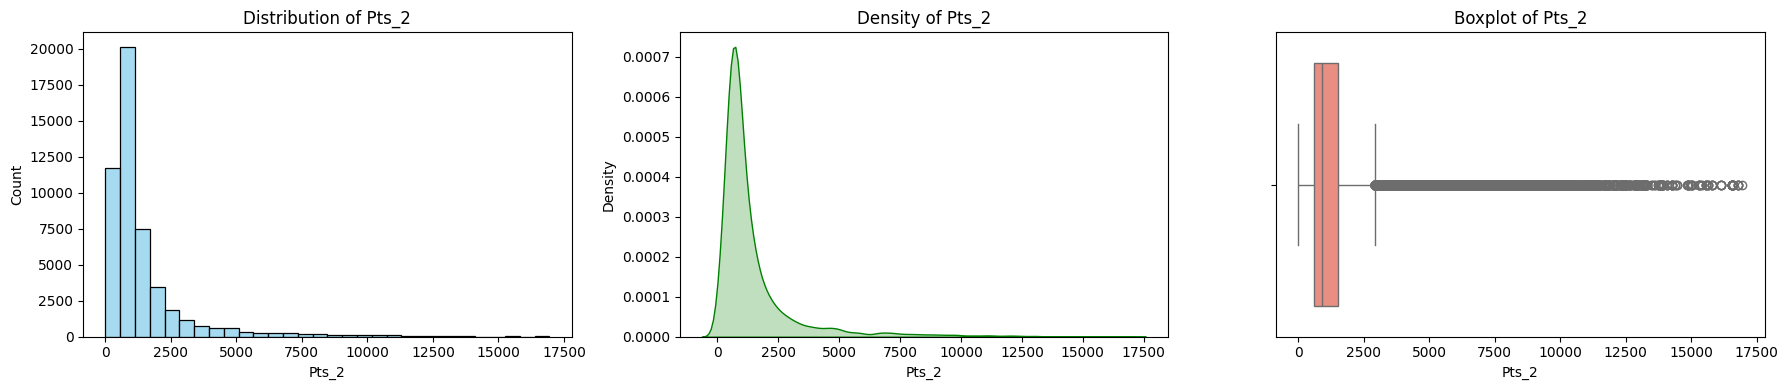

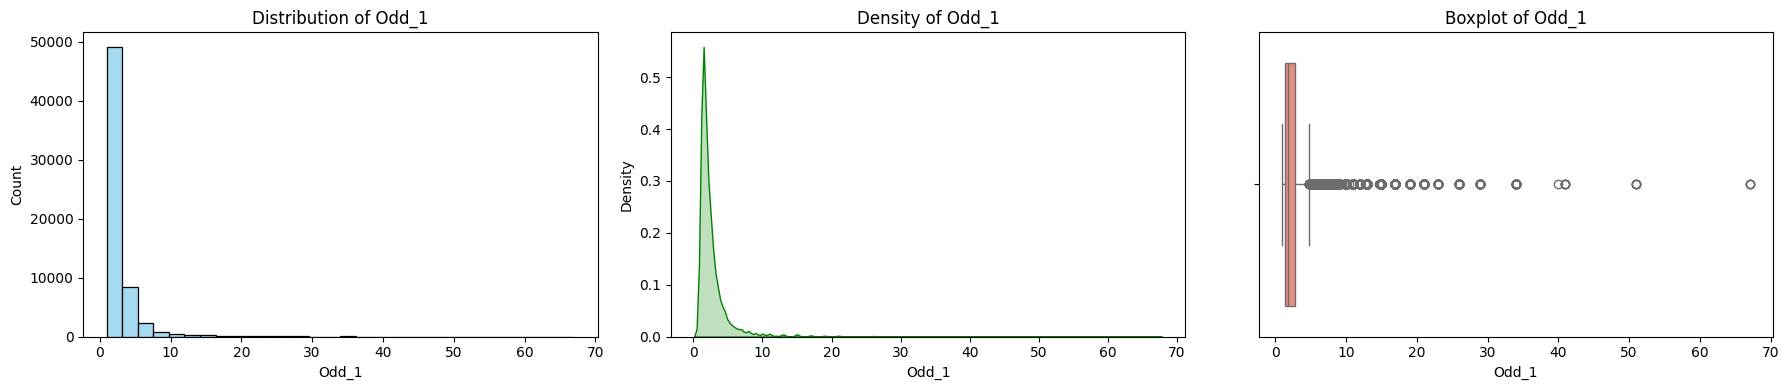

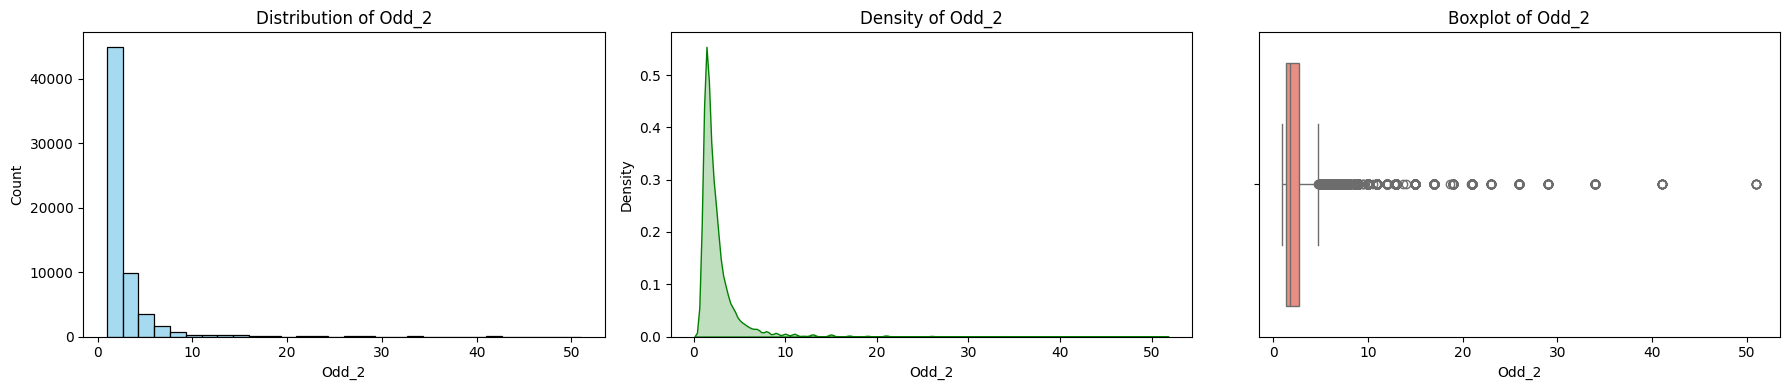

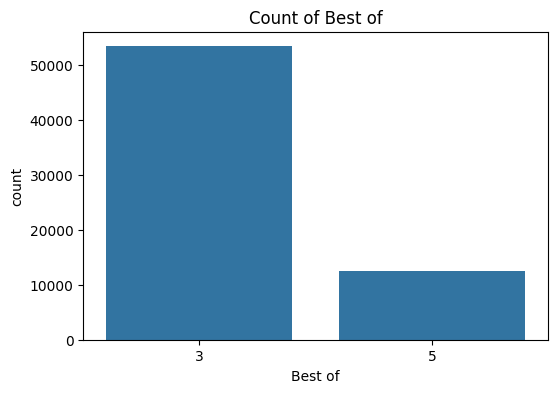

In [12]:
#excluding the "best of"
num_cols = ["Rank_1","Rank_2","Pts_1","Pts_2","Odd_1","Odd_2"]
print("========================================================Univariate Analysis of Numerical Variables===========================================")
for col in num_cols:
    plt.figure(figsize=(18, 4))
    data = df[col].dropna()

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(data, bins=30, kde=False, color='skyblue')
    plt.title(f'Distribution of {col}')

    # KDE Plot
    plt.subplot(1, 3, 2)
    sns.kdeplot(data, fill=True, color='green')
    plt.title(f'Density of {col}')

    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=data, color='salmon')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()
plt.figure(figsize=(6,4))
sns.countplot(x='Best of', data=df)
plt.title('Count of Best of')
plt.show()

### Insights from Numerical Variable Distributions

1. `Rank_1` and `Rank_2` are highly right-skewed.

2. Most players have rankings below 200, while only a small number of players have extremely large rankings above 1000.

3. The boxplots for `Rank_1` and `Rank_2` show many outliers, but these are realistic because lower-ranked and qualifying players are also included in the dataset.

4. `Pts_1` and `Pts_2` are also strongly right-skewed.

5. Most ATP point values are concentrated below 2000, while only a few top players have ATP points above 10,000.

6. The presence of very large ATP point values indicates a large gap between elite players and lower-ranked players.

7. `Odd_1` and `Odd_2` are highly right-skewed as well.

8. Most betting odds are concentrated between 1 and 5, meaning that most matches involve reasonably competitive players.

9. A small number of matches have extremely high betting odds above 20, which likely represent strong favorite-versus-underdog matches.

10. The boxplots for ATP points and betting odds show many extreme values, but these should generally be retained because they contain important information about player strength and expected match outcome.

11. Since rankings, ATP points, and betting odds are all strongly skewed, log transformation may later help reduce skewness and improve model performance.

12. `Best of` contains only two values: 3 and 5.

13. Most matches are best-of-3, while a much smaller number are best-of-5.

14. Best-of-5 matches likely correspond to Grand Slam tournaments, while best-of-3 matches represent most ATP tour events.

### 4.1.3 Categorical Variables

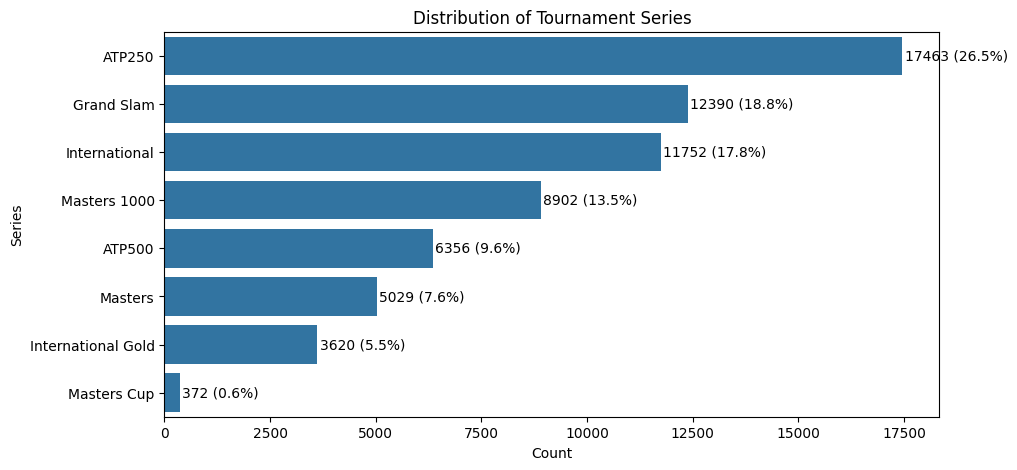

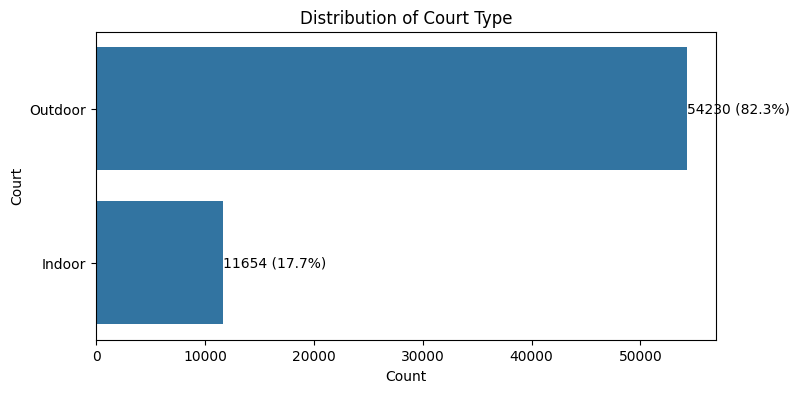

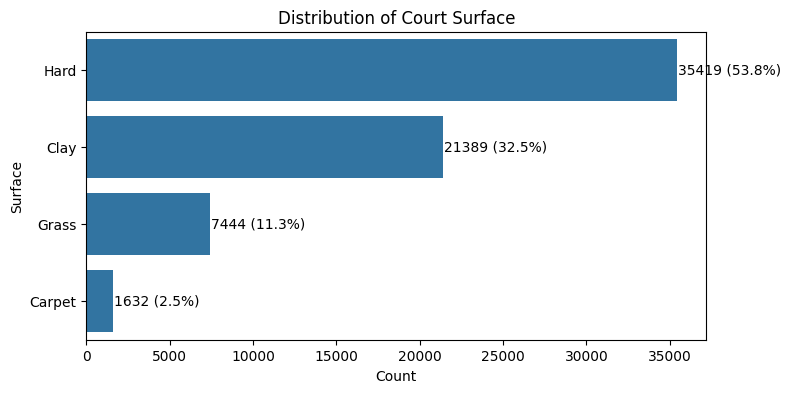

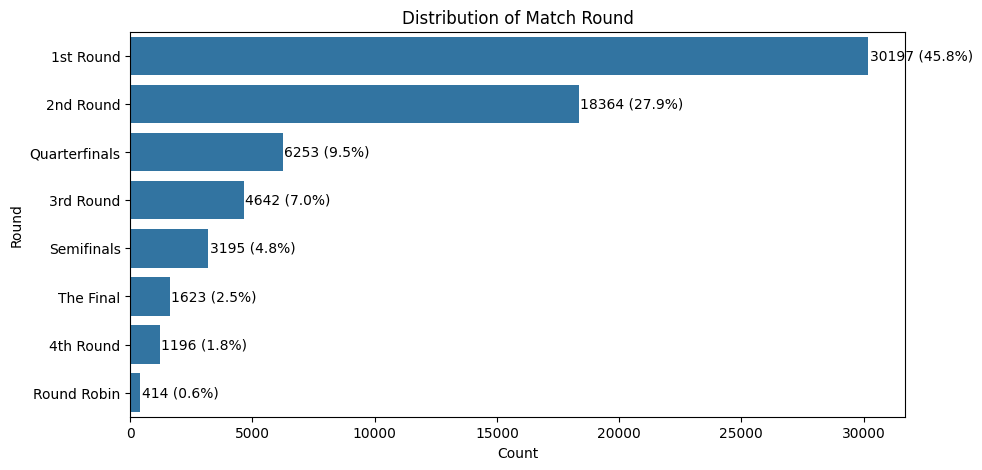

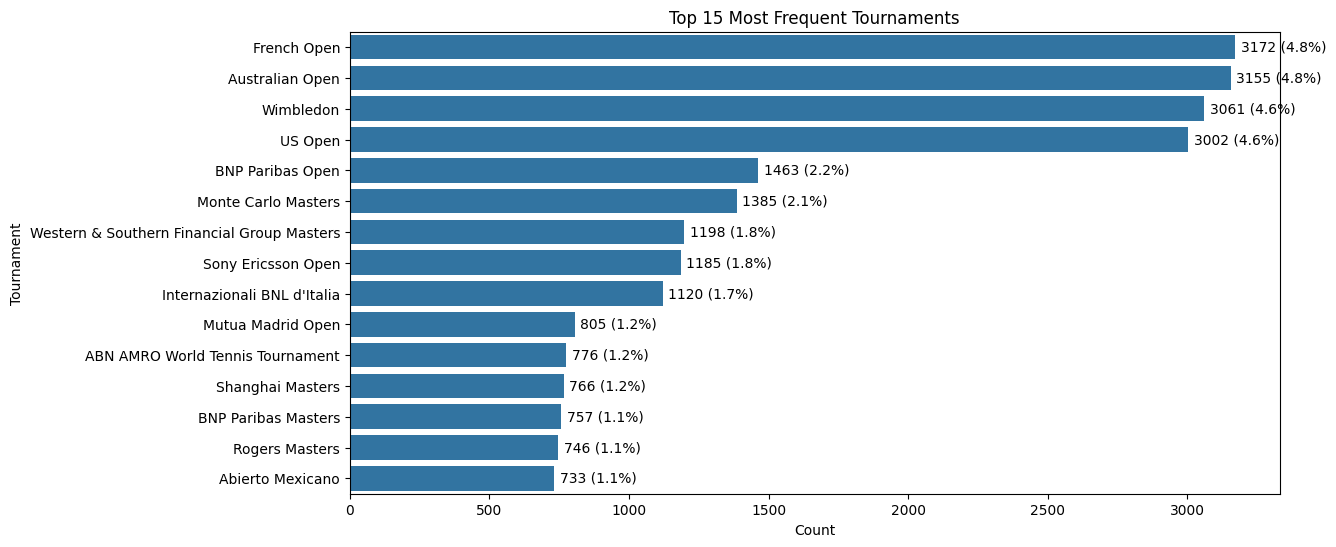

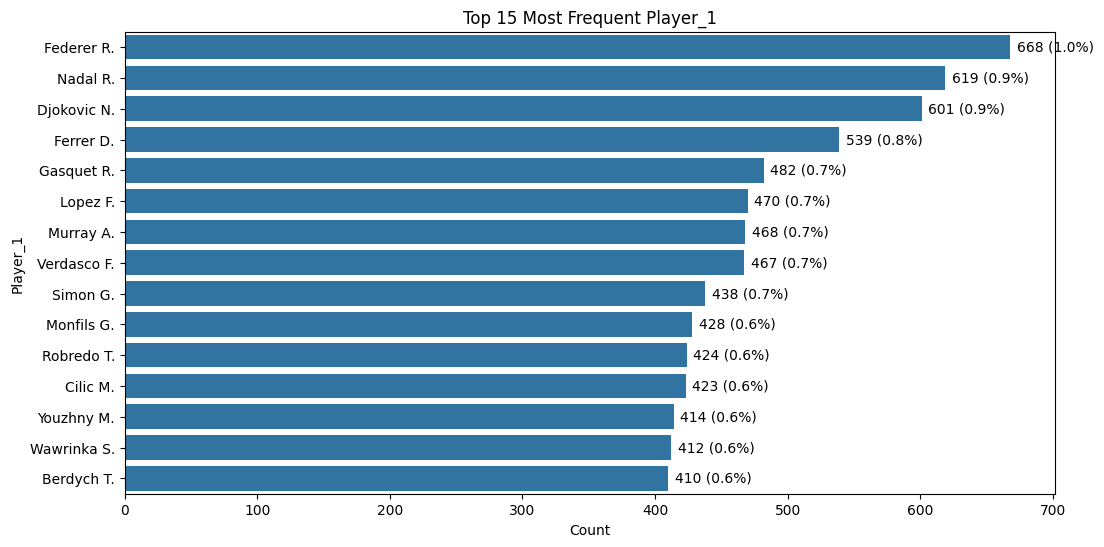

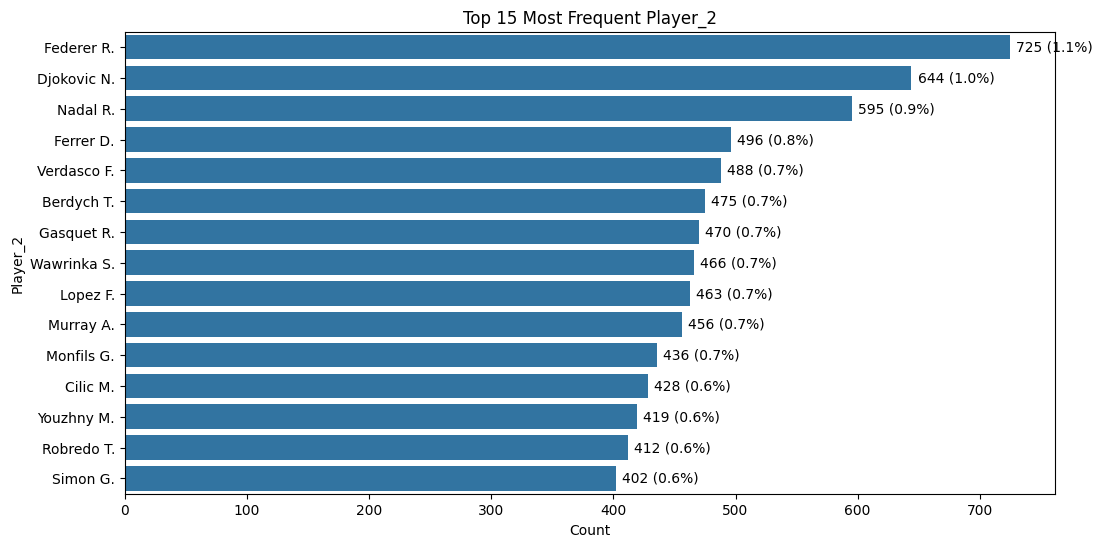

In [13]:
# =========================================================
# UNIVARIATE ANALYSIS OF CATEGORICAL VARIABLES
# =========================================================
# =========================================================
# SERIES
# =========================================================
plt.figure(figsize=(10,5))

series_counts = df['Series'].value_counts()
series_percent = (series_counts / len(df)) * 100

ax = sns.barplot(x=series_counts.values, y=series_counts.index)

for i, (count, percent) in enumerate(zip(series_counts.values, series_percent.values)):
    ax.text(count + 50, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Distribution of Tournament Series')
plt.xlabel('Count')
plt.ylabel('Series')
plt.show()
# =========================================================
# COURT
# =========================================================
plt.figure(figsize=(8,4))
court_counts = df['Court'].value_counts()
court_percent = (court_counts / len(df)) * 100
ax = sns.barplot(x=court_counts.values, y=court_counts.index)

for i, (count, percent) in enumerate(zip(court_counts.values, court_percent.values)):
    ax.text(count + 50, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Distribution of Court Type')
plt.xlabel('Count')
plt.ylabel('Court')
plt.show()

# =========================================================
# SURFACE
# =========================================================
plt.figure(figsize=(8,4))

surface_counts = df['Surface'].value_counts()
surface_percent = (surface_counts / len(df)) * 100

ax = sns.barplot(x=surface_counts.values, y=surface_counts.index)

for i, (count, percent) in enumerate(zip(surface_counts.values, surface_percent.values)):
    ax.text(count + 50, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Distribution of Court Surface')
plt.xlabel('Count')
plt.ylabel('Surface')
plt.show()

# =========================================================
# ROUND
# =========================================================
plt.figure(figsize=(10,5))

round_counts = df['Round'].value_counts()
round_percent = (round_counts / len(df)) * 100

ax = sns.barplot(x=round_counts.values, y=round_counts.index)

for i, (count, percent) in enumerate(zip(round_counts.values, round_percent.values)):
    ax.text(count + 50, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Distribution of Match Round')
plt.xlabel('Count')
plt.ylabel('Round')
plt.show()

# =========================================================
# TOURNAMENT
# =========================================================
plt.figure(figsize=(12,6))

tournament_counts = df['Tournament'].value_counts().head(15)
tournament_percent = (tournament_counts / len(df)) * 100

ax = sns.barplot(x=tournament_counts.values, y=tournament_counts.index)

for i, (count, percent) in enumerate(zip(tournament_counts.values, tournament_percent.values)):
    ax.text(count + 20, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Top 15 Most Frequent Tournaments')
plt.xlabel('Count')
plt.ylabel('Tournament')
plt.show()

# =========================================================
# PLAYER 1
# =========================================================
plt.figure(figsize=(12,6))

player1_counts = df['Player_1'].value_counts().head(15)
player1_percent = (player1_counts / len(df)) * 100

ax = sns.barplot(x=player1_counts.values, y=player1_counts.index)

for i, (count, percent) in enumerate(zip(player1_counts.values, player1_percent.values)):
    ax.text(count + 5, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Top 15 Most Frequent Player_1')
plt.xlabel('Count')
plt.ylabel('Player_1')
plt.show()

# =========================================================
# PLAYER 2
# =========================================================
plt.figure(figsize=(12,6))

player2_counts = df['Player_2'].value_counts().head(15)
player2_percent = (player2_counts / len(df)) * 100

ax = sns.barplot(x=player2_counts.values, y=player2_counts.index)

for i, (count, percent) in enumerate(zip(player2_counts.values, player2_percent.values)):
    ax.text(count + 5, i, f'{count} ({percent:.1f}%)', va='center')

plt.title('Top 15 Most Frequent Player_2')
plt.xlabel('Count')
plt.ylabel('Player_2')
plt.show()

### Insights from Categorical Variable Distributions

1. ATP250 tournaments are the most common tournament type, representing 26.5% of all matches.

2. Grand Slam tournaments contribute 18.8% of matches, while International and Masters 1000 tournaments also make up a large share of the dataset.

3. Masters Cup tournaments are very rare, representing less than 1% of the data.

4. Outdoor matches dominate the dataset, accounting for 82.3% of all matches.

5. Indoor matches account for only 17.7%, showing that most ATP tournaments are played outdoors.

6. Hard courts are the most common surface, representing 53.8% of all matches.

7. Clay courts are the second most common surface at 32.5%.

8. Grass courts account for 11.3% of matches, while Carpet courts are very rare at only 2.5%.

9. The first round is the most common stage of a tournament, representing 45.8% of all matches.

10. The second round also contributes a large share of matches at 27.9%.

11. Later stages such as semifinals and finals are much less common because only a few players reach those stages in each tournament.

12. The most frequent tournaments are the Grand Slams, including the French Open, Australian Open, Wimbledon, and US Open.

13. This indicates that major tournaments contribute a large share of the dataset.

14. Roger Federer appears most frequently in both `Player_1` and `Player_2`, followed by Rafael Nadal and Novak Djokovic

15. This suggests that top players participate in many tournaments over long careers, causing them to appear more frequently in the dataset.

16. Since player names have very high cardinality, using raw player names directly in modelling may create too many features.

17. Instead, player-based feature engineering such as ranking differences, ATP points differences, and betting odds differences will likely be more useful.

## 4.2 Bivarirate Analysis

In [14]:
df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,target
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,63.0,77.0,NaN,NaN,NaN,NaN,1
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,56.0,5.0,NaN,NaN,NaN,NaN,0
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,40.0,655.0,NaN,NaN,NaN,NaN,1
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,87.0,65.0,NaN,NaN,NaN,NaN,0
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,81.0,198.0,NaN,NaN,NaN,NaN,1


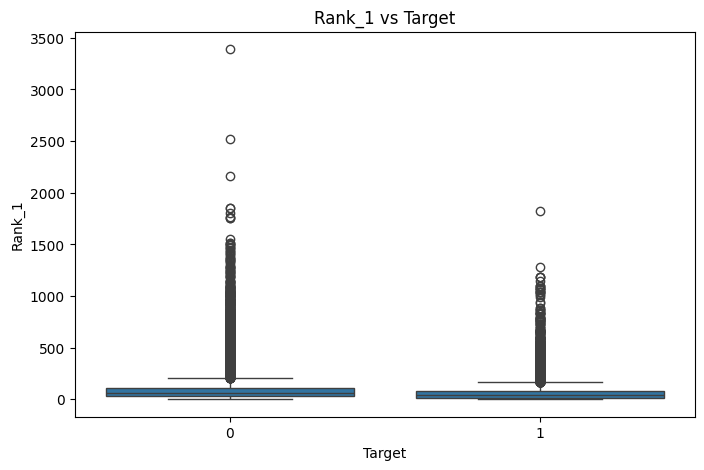

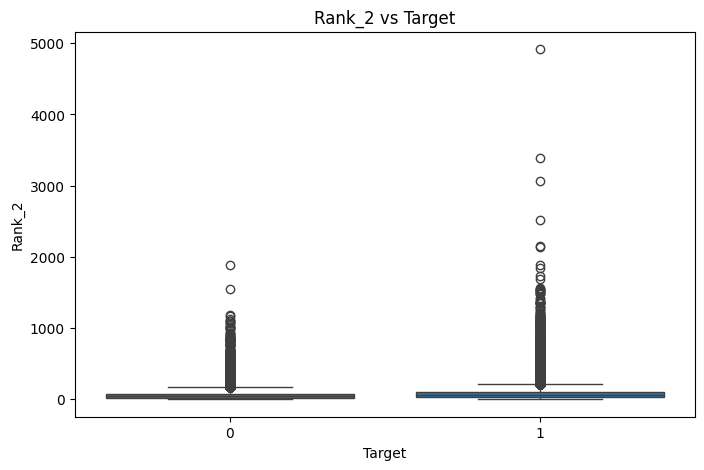

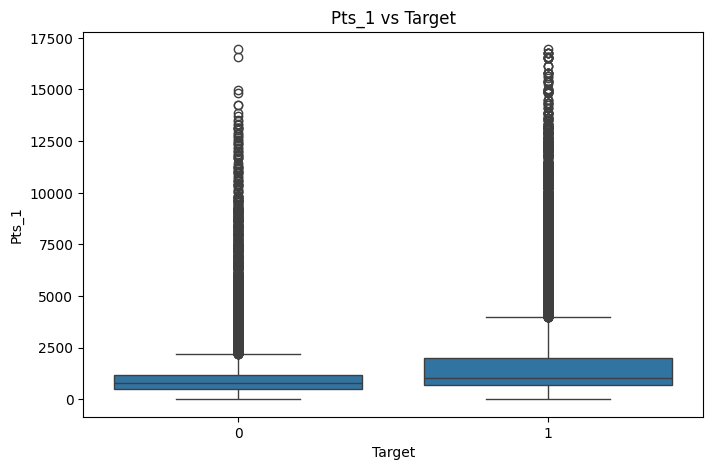

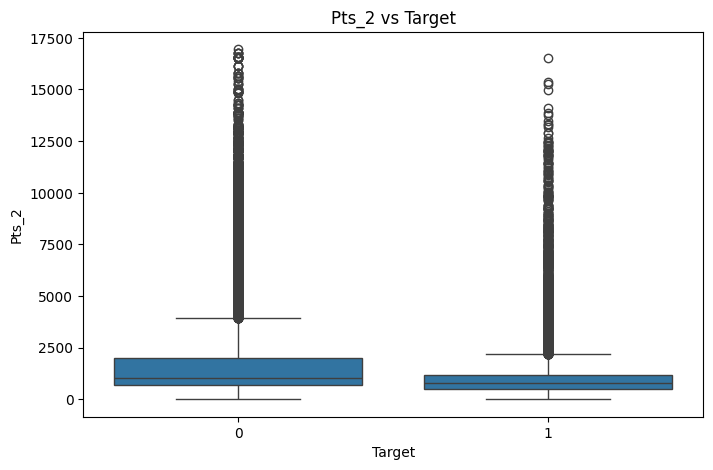

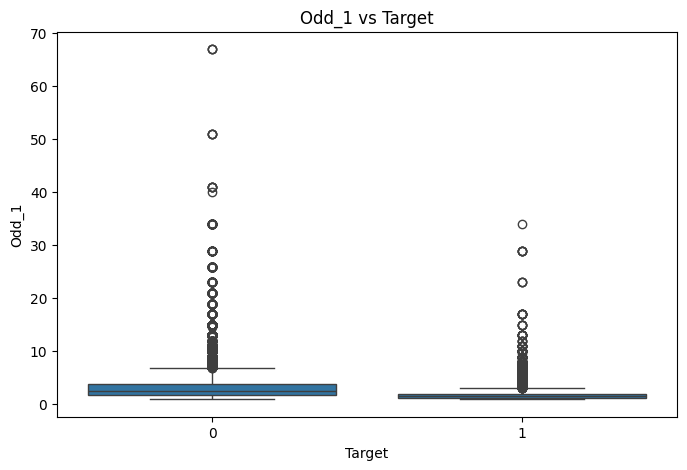

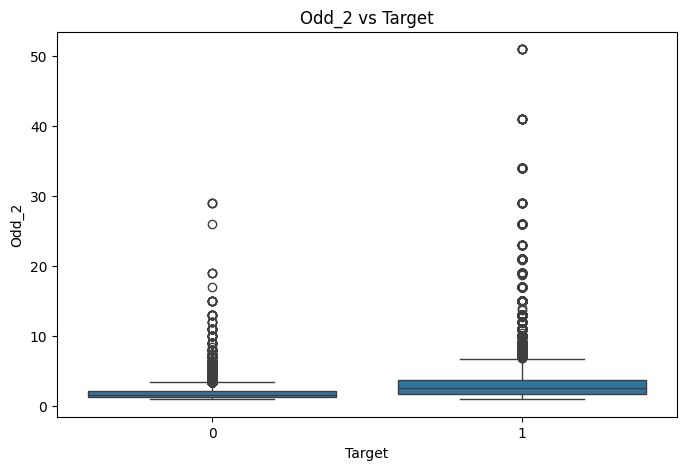

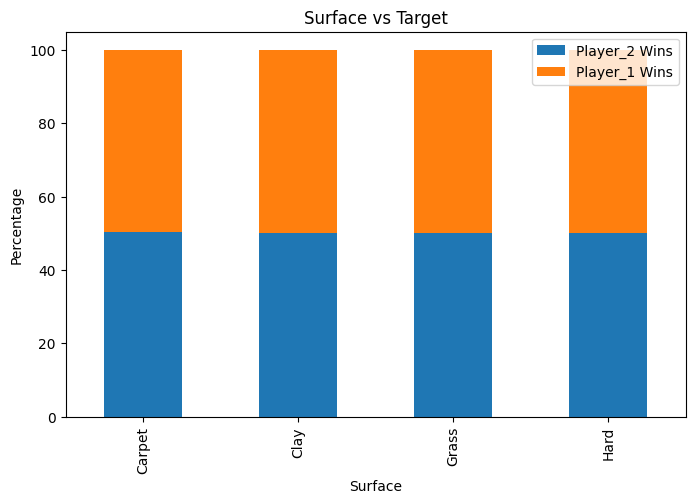

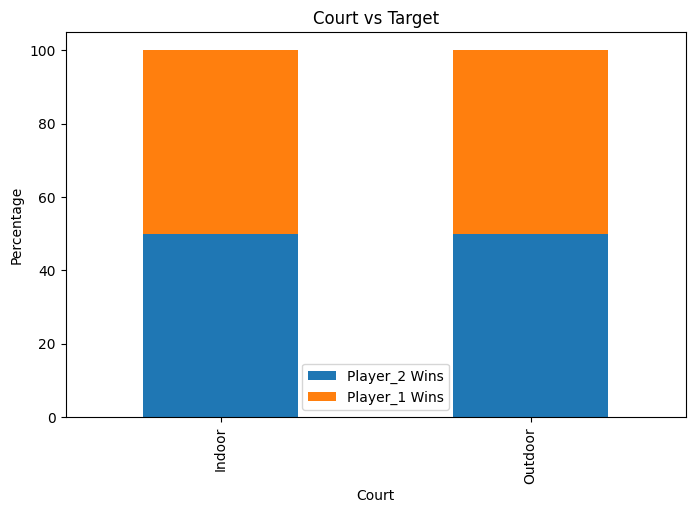

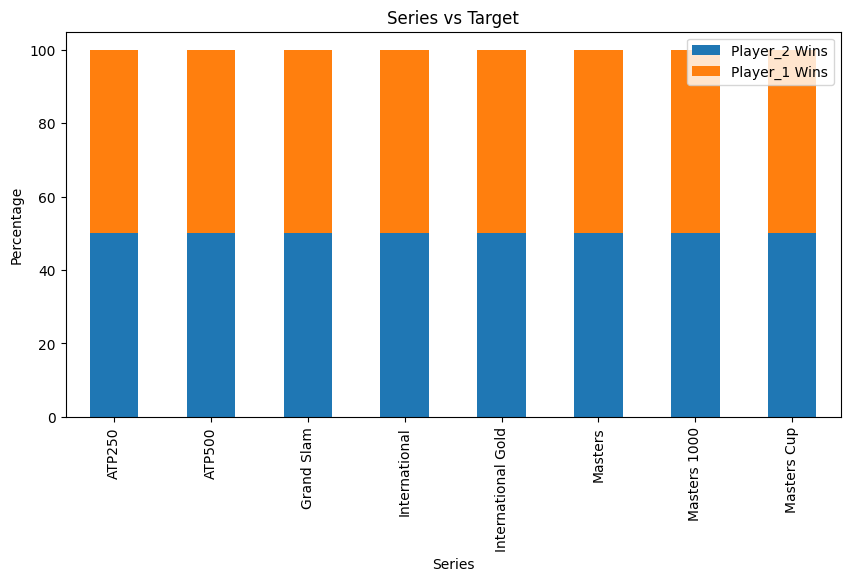

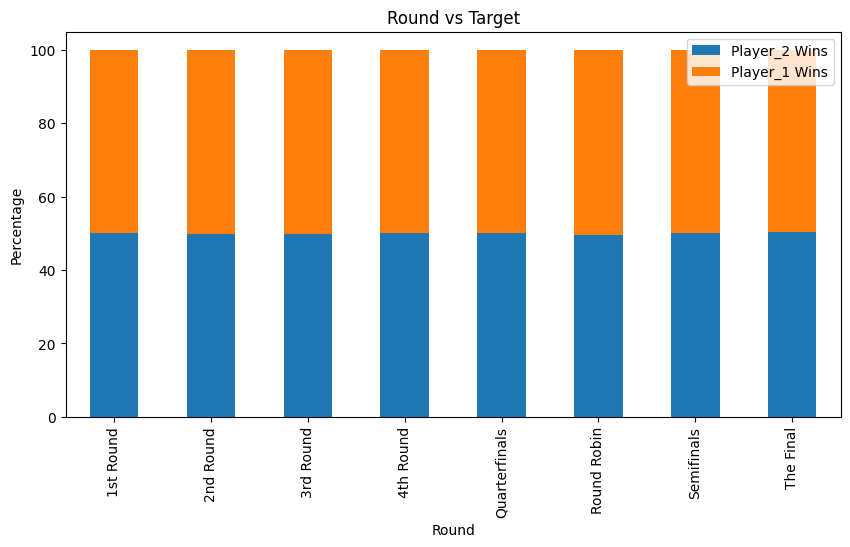

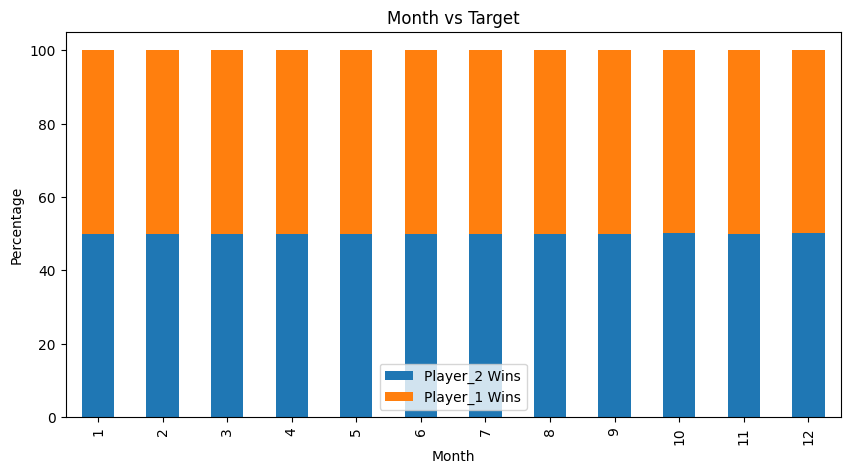

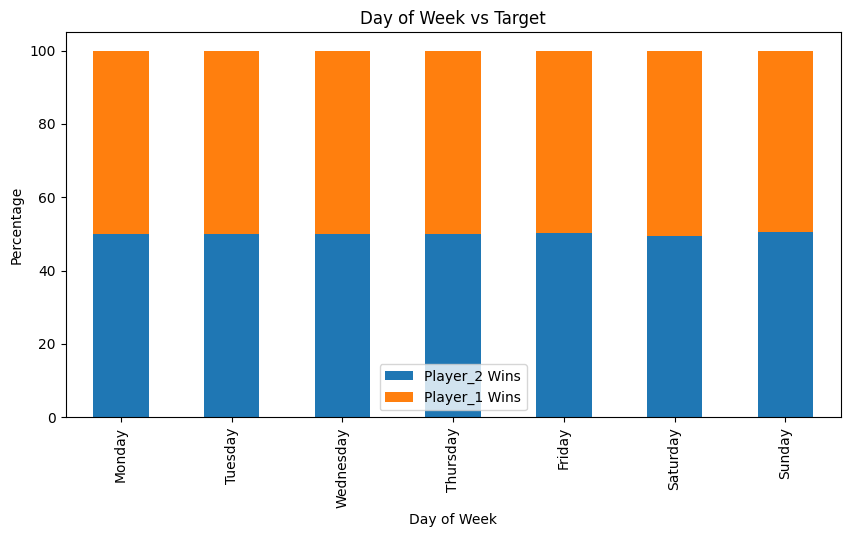

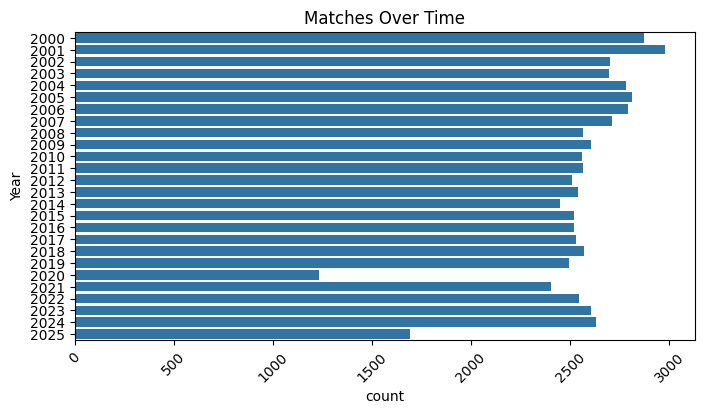

<Figure size 1000x500 with 0 Axes>

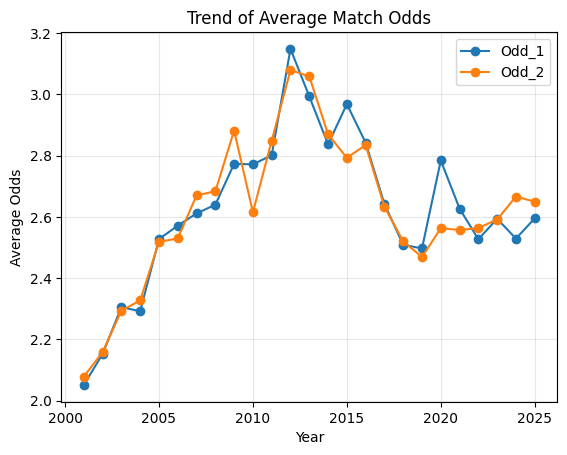

In [15]:
# =========================================================
# DATE FEATURE ENGINEERING FOR BIVARIATE ANALYSIS
# =========================================================
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
# =========================================================
# NUMERICAL VARIABLES VS TARGET
# =========================================================

for col in num_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.boxplot(x=target, y=col, data=df)
    
    plt.title(f'{col} vs Target')
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.show()
# =========================================================
# SURFACE VS TARGET
# =========================================================

surface_target = pd.crosstab(df['Surface'], df[target], normalize='index') * 100

surface_target.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Surface vs Target')
plt.xlabel('Surface')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# COURT VS TARGET
# =========================================================

court_target = pd.crosstab(df['Court'], df[target], normalize='index') * 100

court_target.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Court vs Target')
plt.xlabel('Court')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# SERIES VS TARGET
# =========================================================

series_target = pd.crosstab(df['Series'], df[target], normalize='index') * 100

series_target.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title('Series vs Target')
plt.xlabel('Series')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# ROUND VS TARGET
# =========================================================

round_target = pd.crosstab(df['Round'], df[target], normalize='index') * 100

round_target.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title('Round vs Target')
plt.xlabel('Round')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# MONTH VS TARGET
# =========================================================

month_target = pd.crosstab(df['Month'], df[target], normalize='index') * 100

month_target.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title('Month vs Target')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# DAY OF WEEK VS TARGET
# =========================================================

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_target = pd.crosstab(df['Day_of_Week'], df[target], normalize='index') * 100
day_target = day_target.reindex(day_order)

day_target.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title('Day of Week vs Target')
plt.xlabel('Day of Week')
plt.ylabel('Percentage')
plt.legend(['Player_2 Wins', 'Player_1 Wins'])
plt.show()
# =========================================================
# MATCHES OVER TIME
# =========================================================
# ---- Time Trend ----
plt.figure(figsize=(8, 4))
sns.countplot(y='Year', data=df)
plt.xticks(rotation=45)
plt.title("Matches Over Time")
plt.show()
# =========================================================
# average favorite/underdog odds
# =========================================================
# Check if the average favorite/underdog odds have shifted over the years
plt.figure(figsize=(10, 5))
df.groupby('Year')[['Odd_1', 'Odd_2']].mean().plot(kind='line', marker='o')
plt.title("Trend of Average Match Odds")
plt.ylabel("Average Odds")
plt.grid(True, alpha=0.3)
plt.show()


### Insights from Bivariate Analysis

1. `Rank_1` is generally lower when Player 1 wins (`target = 1`) compared to when Player 1 loses (`target = 0`).

2. Since lower ATP ranking values indicate stronger players, this suggests that Player 1 is more likely to win when Player 1 has a better ranking.

3. `Rank_2` tends to be higher when Player 1 wins, which means Player 2 is generally weaker in those matches.

4. `Pts_1` is noticeably higher when Player 1 wins.

5. `Pts_2` is generally lower when Player 1 wins.

6. This shows that ATP points are an important indicator of player strength and likely have predictive power.

7. `Odd_1` is much lower when Player 1 wins.

8. `Odd_2` is much higher when Player 1 wins.

9. This suggests that betting odds are one of the strongest predictors because bookmakers already reflect expected match outcomes.

10. Surface does not appear to create large differences in Player 1 versus Player 2 win percentages.

11. Court type also shows almost identical win percentages for Player 1 and Player 2.

12. Tournament series categories have nearly balanced win distributions, suggesting that series alone may not strongly affect the target variable.

13. Match round also appears to have very little effect on the probability of Player 1 winning.

14. Month and Day of Week show almost identical target distributions across all categories.

15. This suggests that date-based features may not have strong direct predictive power on their own.

16. Overall, ranking, ATP points, and betting odds appear to be much stronger predictors than categorical variables such as surface, court type, tournament round, or month.

17. Relative difference-based features such as rank difference, points difference, and odds difference are likely to be even more useful than raw values alone.

## 4.3 Multivarirate Analysis

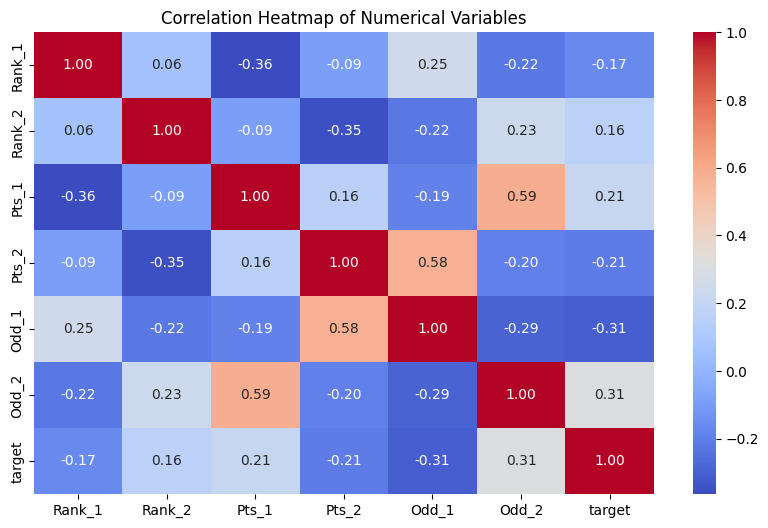

Multicollinearity check of Numerical Variables
  Feature       VIF
0   Odd_2  3.330189
1   Odd_1  3.300059
2   Pts_1  3.148509
3   Pts_2  3.066991
4  Rank_1  1.646344
5  Rank_2  1.601836


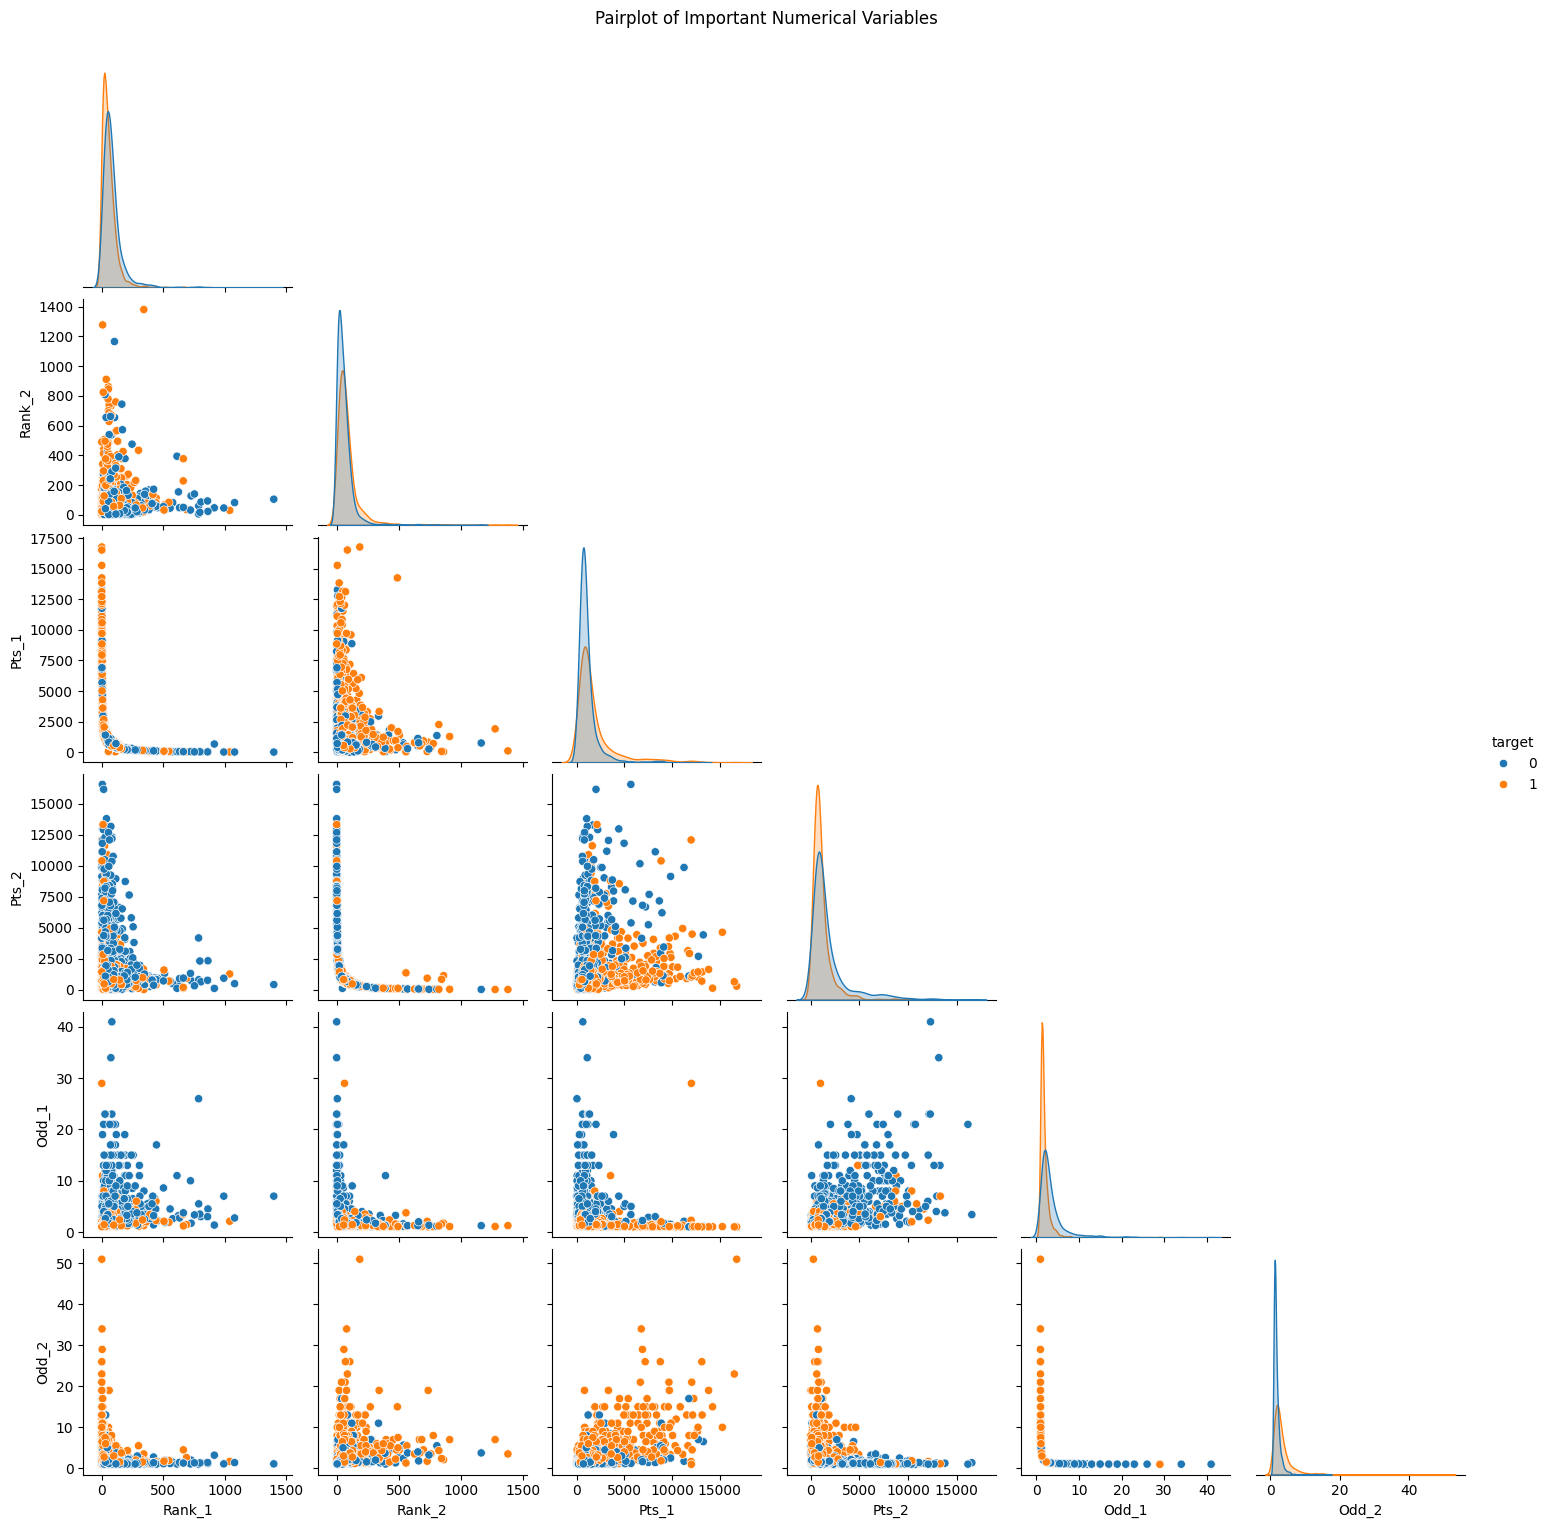

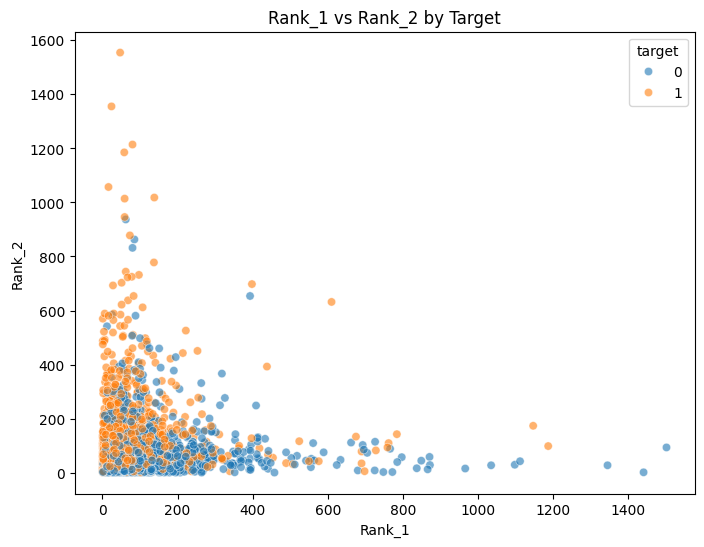

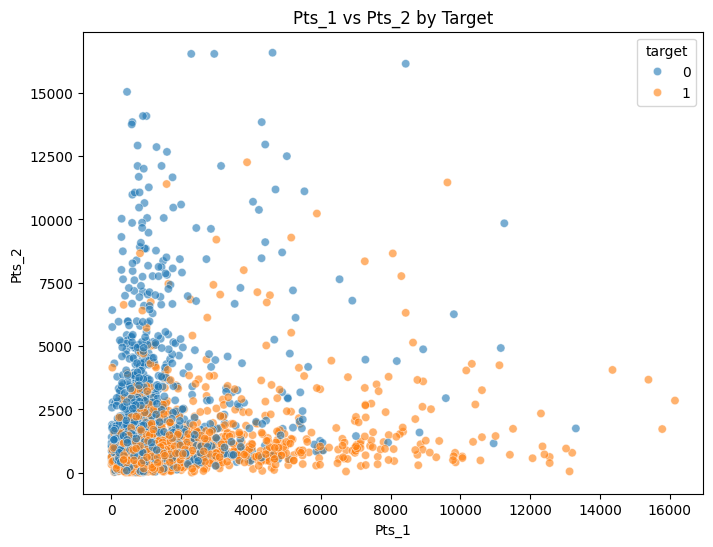

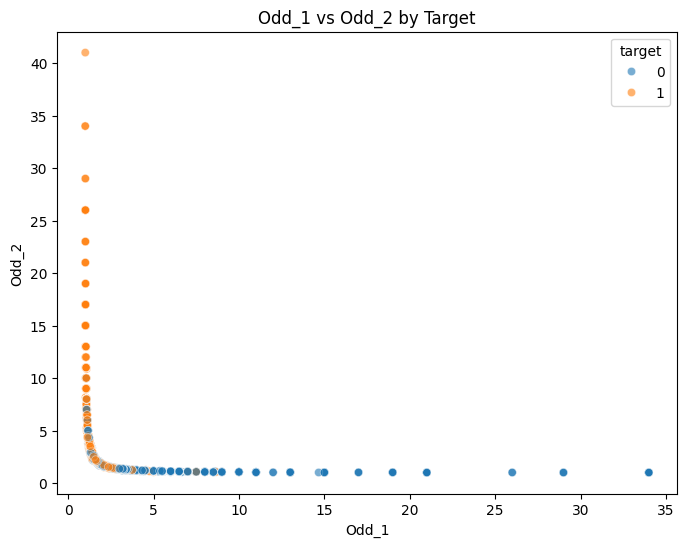

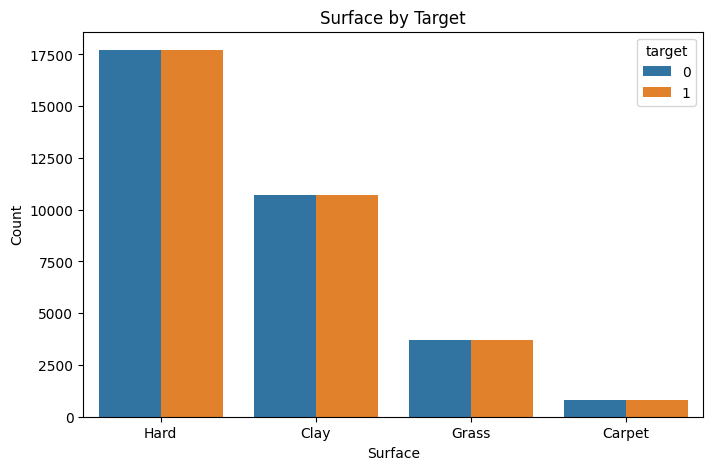

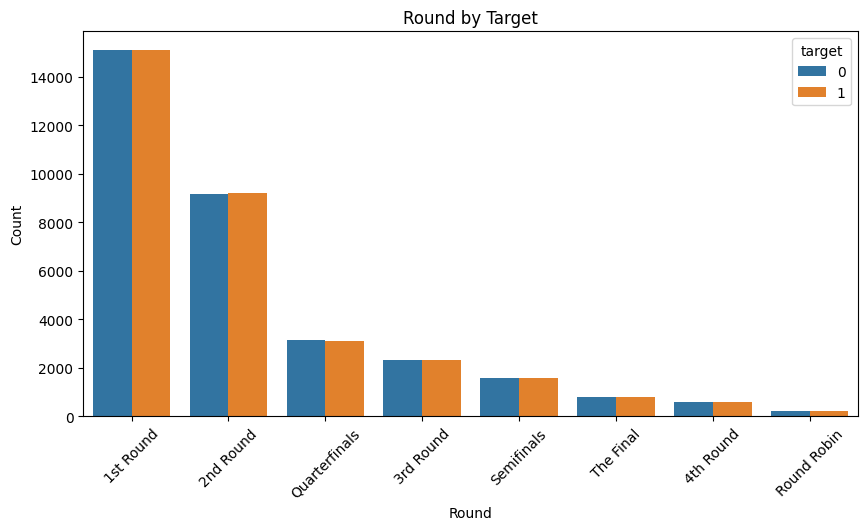

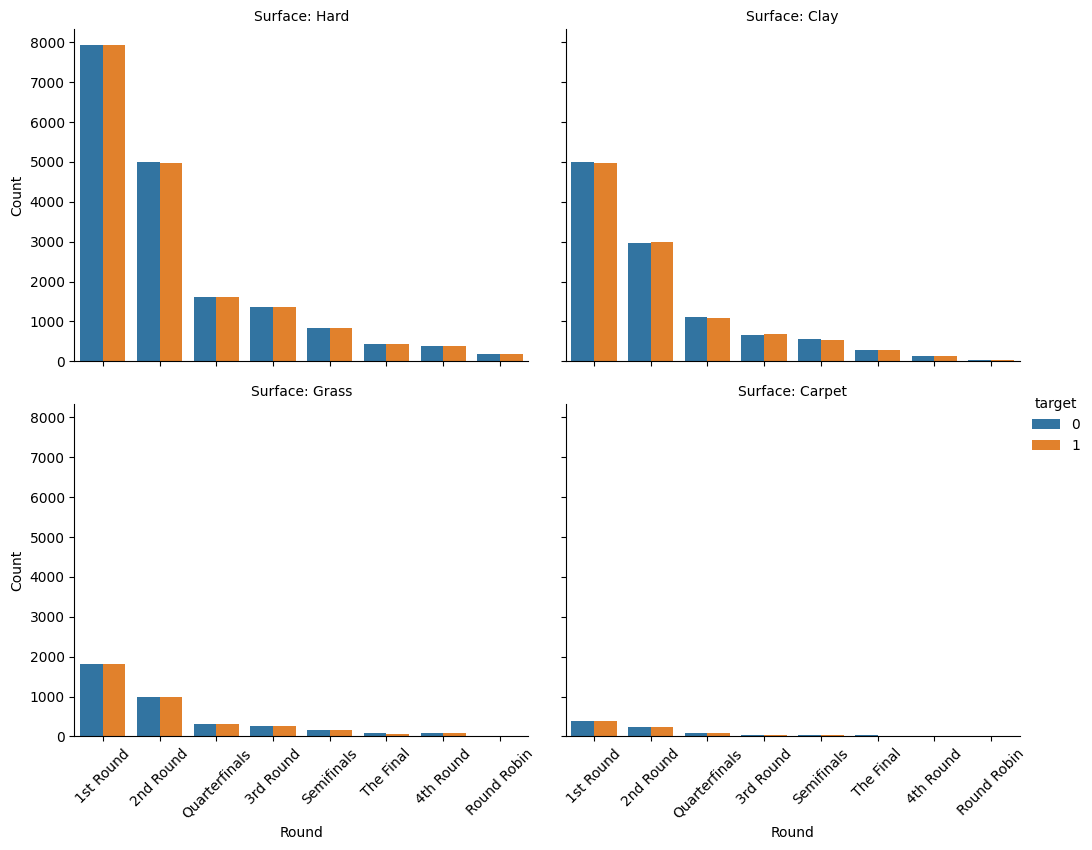

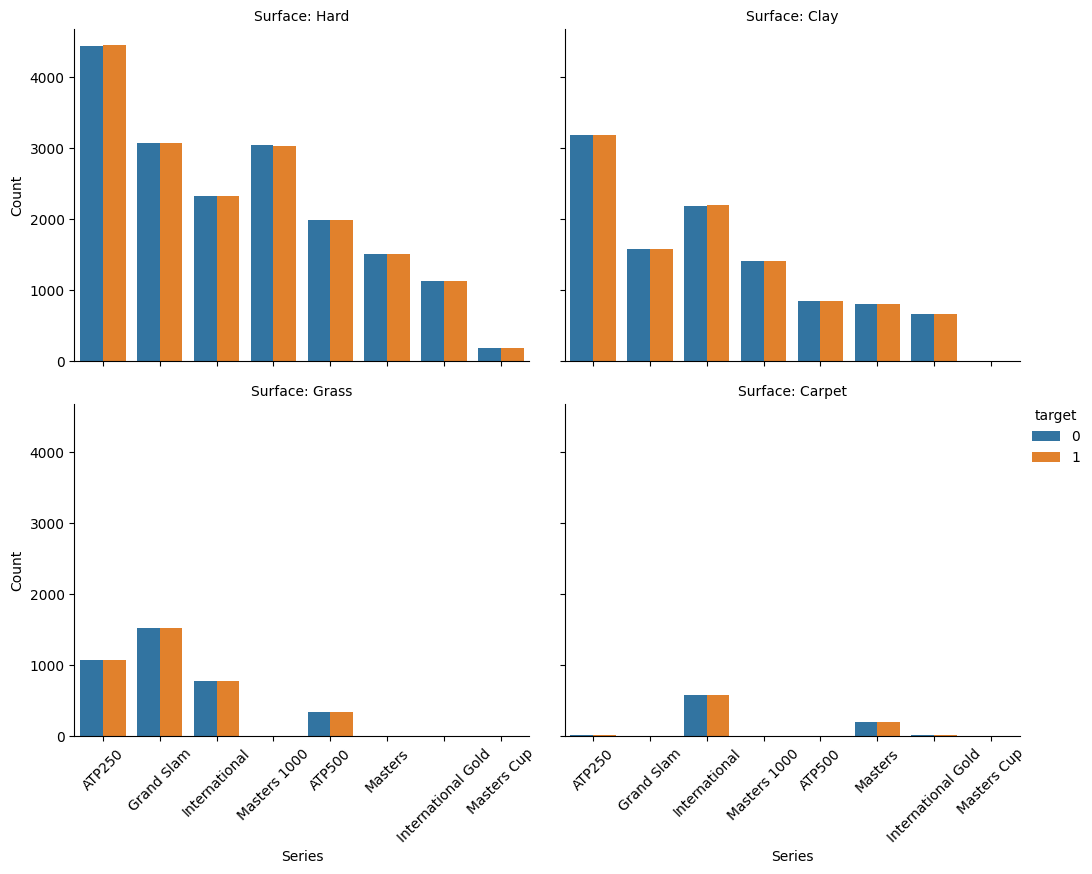

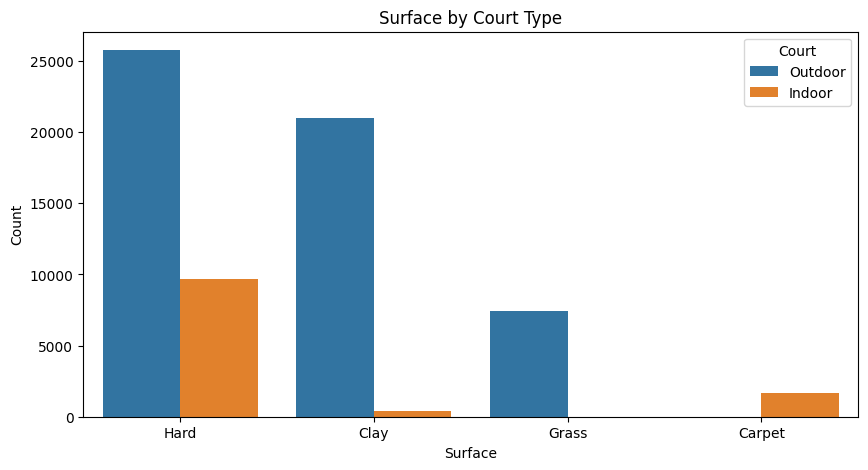

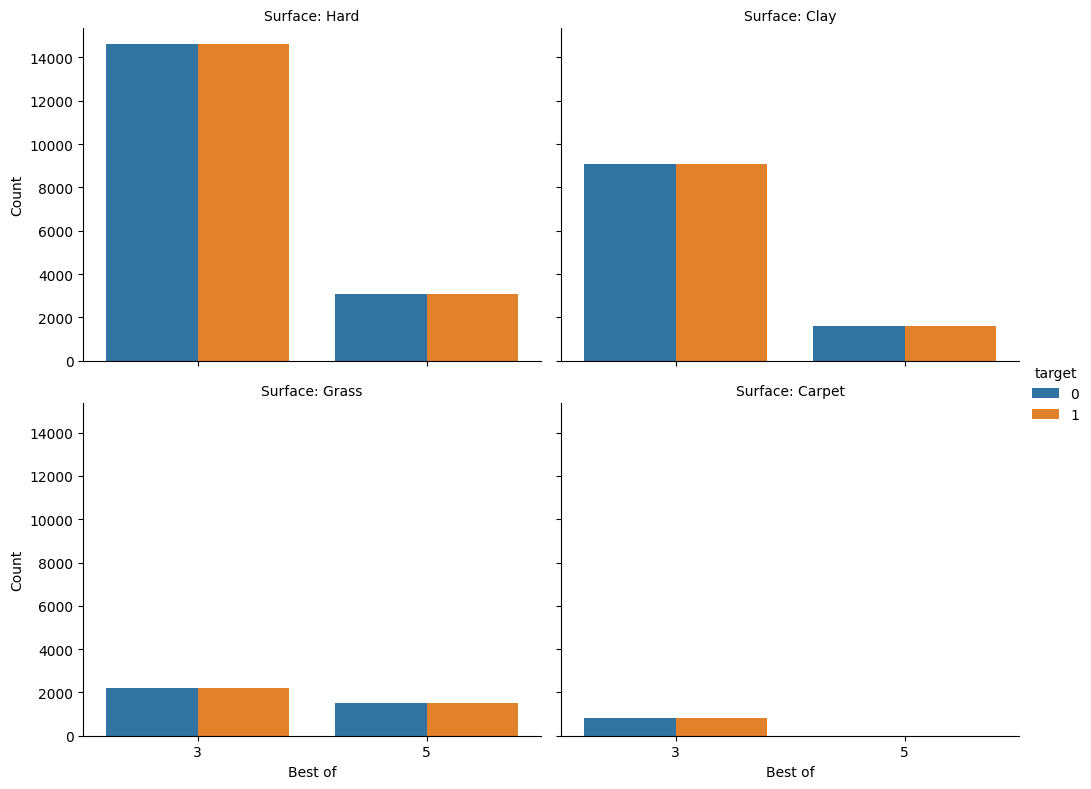

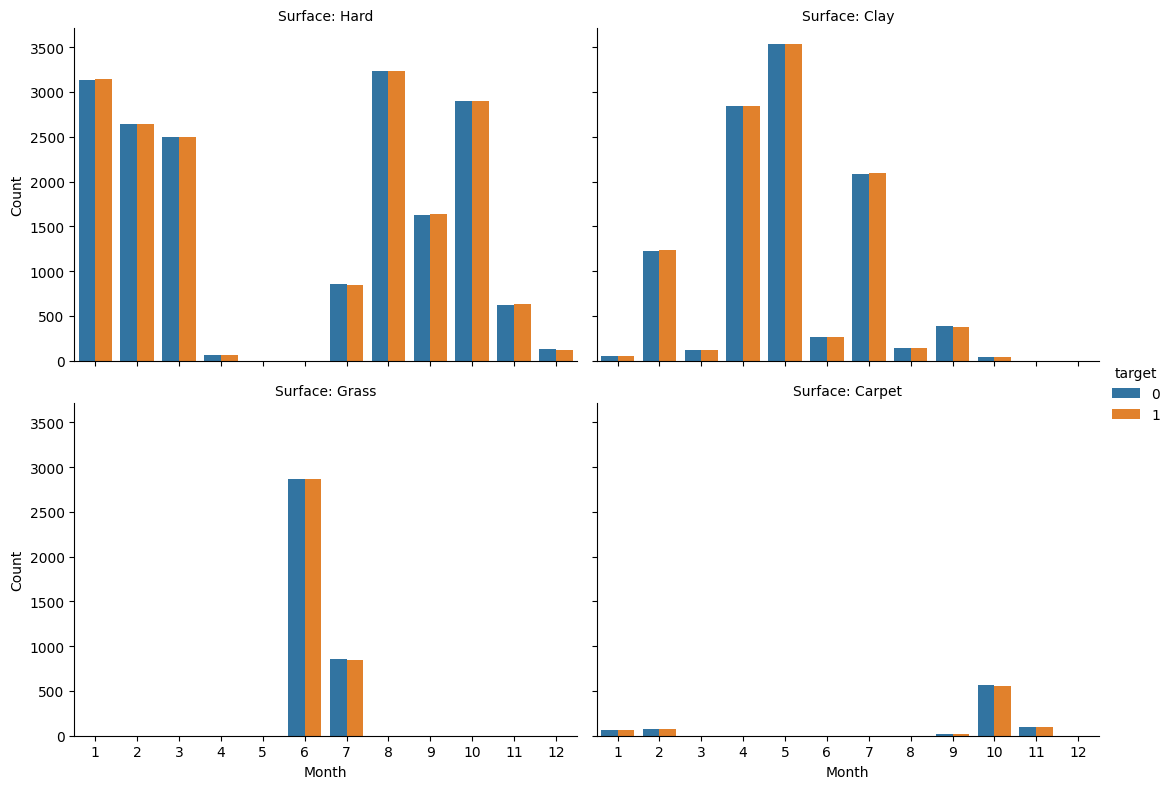

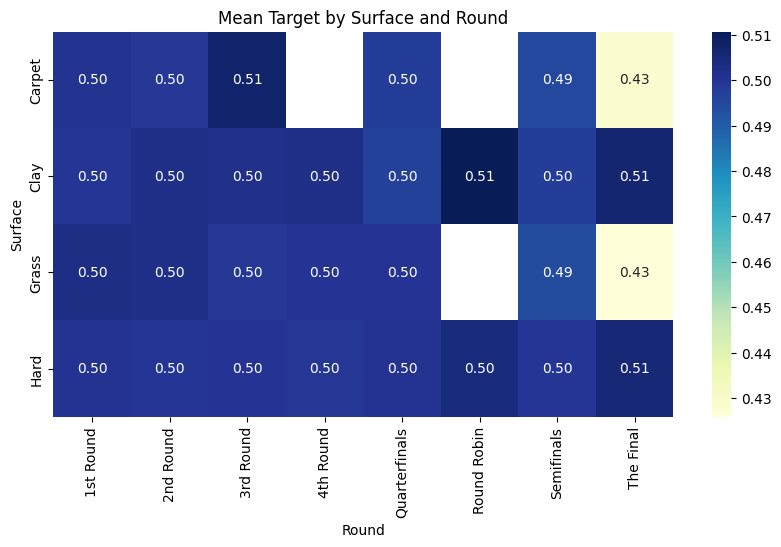

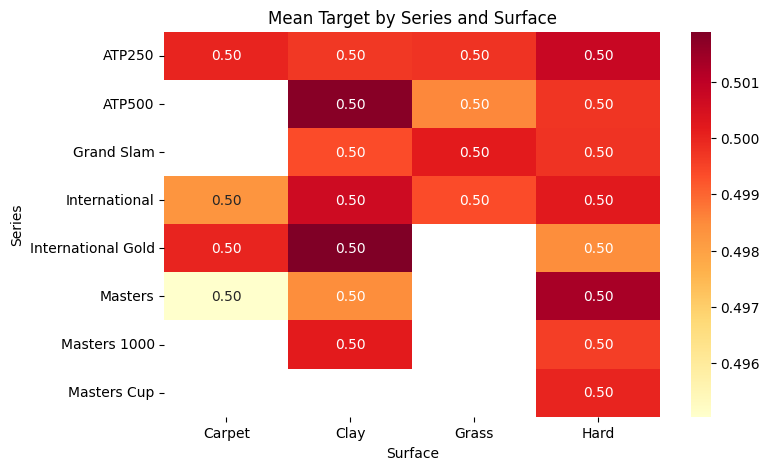

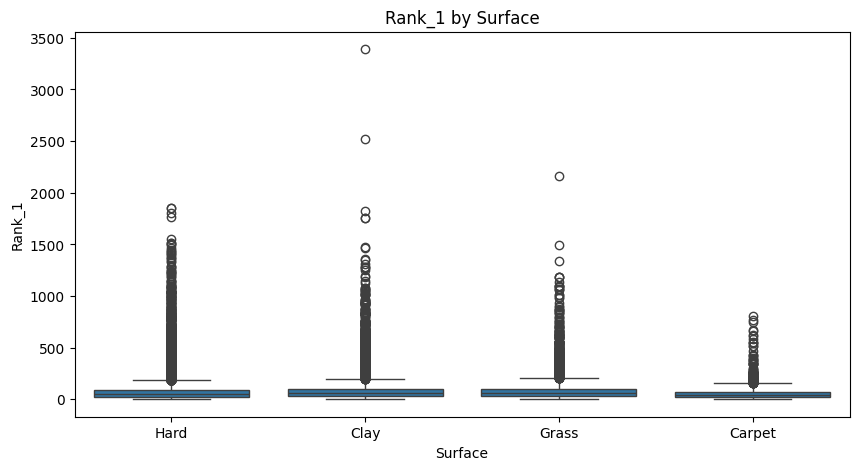

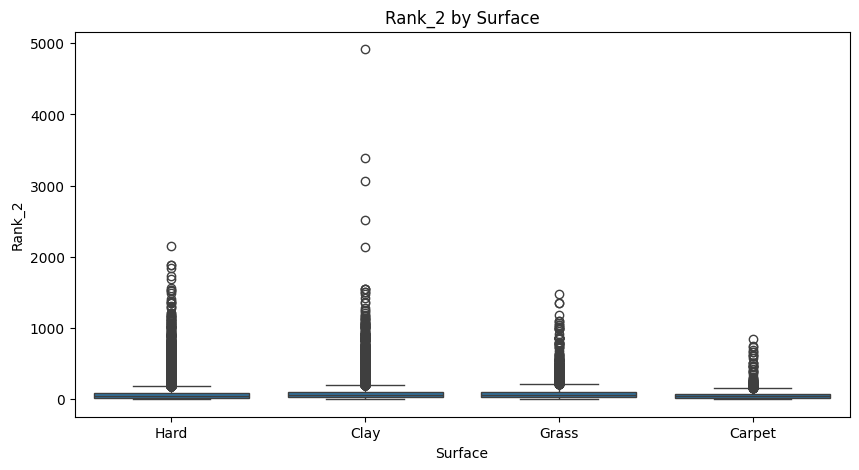

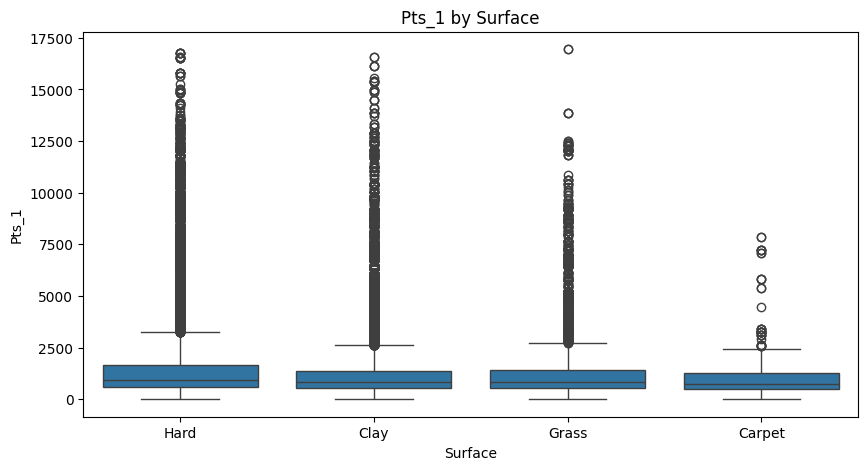

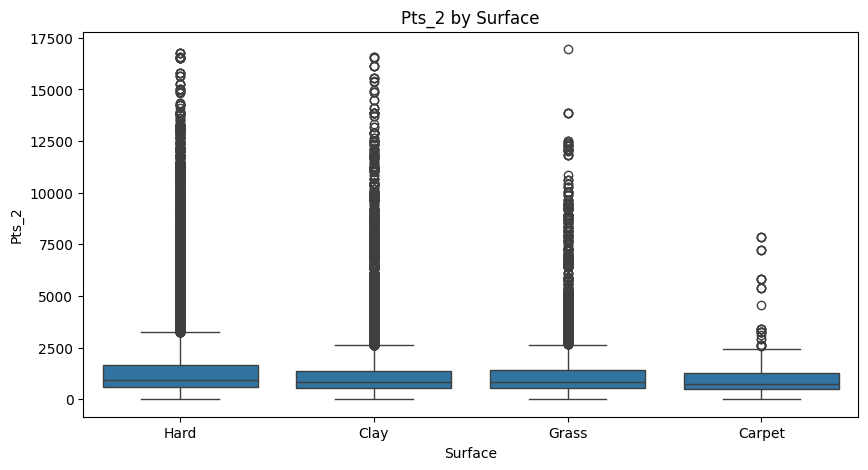

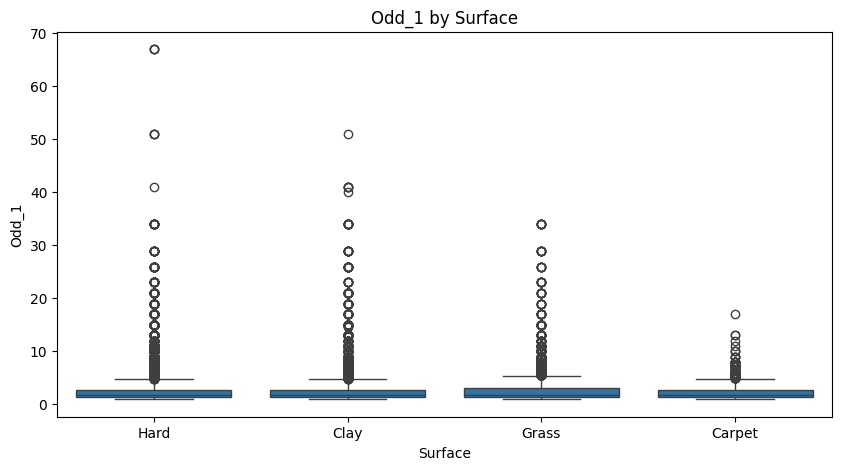

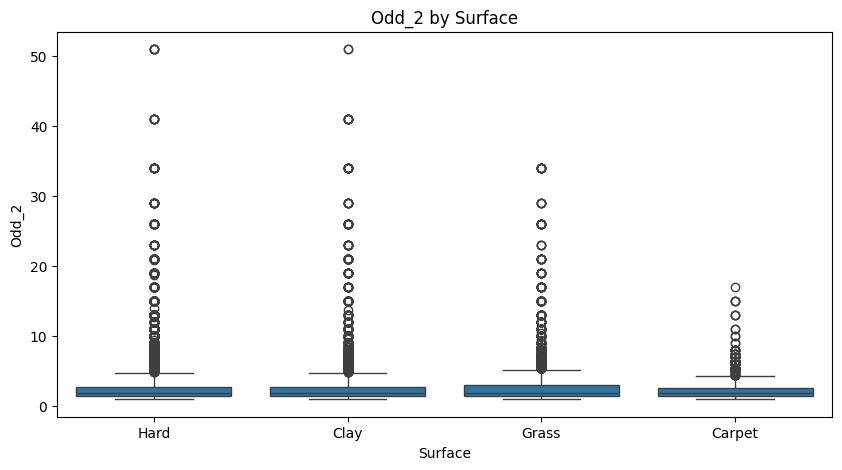

In [16]:
# =========================================================
# 1. CORRELATION HEATMAP OF NUMERICAL VARIABLES
# =========================================================

plt.figure(figsize=(10, 6))

corr_matrix = df[num_cols + [target]].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()
# =========================================================
# VIF (MULTICOLLINEARITY CHECK)
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numerical variables
vif_data = df[num_cols].copy()

# Drop missing values temporarily for VIF calculation
vif_data = vif_data.dropna()
print('Multicollinearity check of Numerical Variables')
# Create VIF dataframe
vif_df = pd.DataFrame()
vif_df['Feature'] = vif_data.columns
vif_df['VIF'] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(vif_data.shape[1])
]

# Sort VIF values
vif_df = vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print(vif_df)
# =========================================================
# 2. PAIRPLOT OF IMPORTANT NUMERICAL VARIABLES
# =========================================================

important_num_cols = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', target]

sns.pairplot(
    df[important_num_cols].dropna().sample(3000, random_state=42),
    hue=target,
    corner=True
)

plt.suptitle('Pairplot of Important Numerical Variables', y=1.02)
plt.show()
# =========================================================
# 3. RANK_1 VS RANK_2 COLORED BY TARGET
# =========================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Rank_1',
    y='Rank_2',
    hue=target,
    alpha=0.6
)

plt.title('Rank_1 vs Rank_2 by Target')
plt.xlabel('Rank_1')
plt.ylabel('Rank_2')
plt.show()
# =========================================================
# 4. PTS_1 VS PTS_2 COLORED BY TARGET
# =========================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Pts_1',
    y='Pts_2',
    hue=target,
    alpha=0.6
)

plt.title('Pts_1 vs Pts_2 by Target')
plt.xlabel('Pts_1')
plt.ylabel('Pts_2')
plt.show()
# =========================================================
# 5. ODD_1 VS ODD_2 COLORED BY TARGET
# =========================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Odd_1',
    y='Odd_2',
    hue=target,
    alpha=0.6
)

plt.title('Odd_1 vs Odd_2 by Target')
plt.xlabel('Odd_1')
plt.ylabel('Odd_2')
plt.show()
# =========================================================
# 6. SURFACE + TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Surface', hue=target)

plt.title('Surface by Target')
plt.xlabel('Surface')
plt.ylabel('Count')
plt.show()
# =========================================================
# 7. ROUND + TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='Round', hue=target, order=df['Round'].value_counts().index)

plt.title('Round by Target')
plt.xlabel('Round')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
# =========================================================
# 8. SURFACE + ROUND + TARGET
# =========================================================

g = sns.catplot(
    data=df,
    x='Round',
    hue=target,
    col='Surface',
    kind='count',
    col_wrap=2,
    height=4,
    aspect=1.3,
    order=df['Round'].value_counts().index
)

g.set_titles("Surface: {col_name}")
g.set_axis_labels("Round", "Count")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.show()
# =========================================================
# 9. SERIES + SURFACE + TARGET
# =========================================================

g = sns.catplot(
    data=df,
    x='Series',
    hue=target,
    col='Surface',
    kind='count',
    col_wrap=2,
    height=4,
    aspect=1.3,
    order=df['Series'].value_counts().index
)

g.set_titles("Surface: {col_name}")
g.set_axis_labels("Series", "Count")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.show()
# =========================================================
# 10. COURT + SURFACE + TARGET
# =========================================================

plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='Surface', hue='Court')

plt.title('Surface by Court Type')
plt.xlabel('Surface')
plt.ylabel('Count')
plt.show()
# =========================================================
# 11. SURFACE + BEST OF + TARGET
# =========================================================

g = sns.catplot(
    data=df,
    x='Best of',
    hue=target,
    col='Surface',
    kind='count',
    col_wrap=2,
    height=4,
    aspect=1.3
)

g.set_titles("Surface: {col_name}")
g.set_axis_labels("Best of", "Count")
plt.show()
# =========================================================
# 12. MONTH + SURFACE + TARGET
# =========================================================

df['Month'] = df['Date'].dt.month

g = sns.catplot(
    data=df,
    x='Month',
    hue=target,
    col='Surface',
    kind='count',
    col_wrap=2,
    height=4,
    aspect=1.4
)

g.set_titles("Surface: {col_name}")
g.set_axis_labels("Month", "Count")
plt.show()
# =========================================================
# 13. PIVOT TABLE: SURFACE + ROUND VS TARGET MEAN
# =========================================================

surface_round_target = pd.pivot_table(
    df,
    values=target,
    index='Surface',
    columns='Round',
    aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(surface_round_target, annot=True, fmt='.2f', cmap='YlGnBu')

plt.title('Mean Target by Surface and Round')
plt.xlabel('Round')
plt.ylabel('Surface')
plt.show()
# =========================================================
# 14. PIVOT TABLE: SERIES + SURFACE VS TARGET MEAN
# =========================================================

series_surface_target = pd.pivot_table(
    df,
    values=target,
    index='Series',
    columns='Surface',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(series_surface_target, annot=True, fmt='.2f', cmap='YlOrRd')

plt.title('Mean Target by Series and Surface')
plt.xlabel('Surface')
plt.ylabel('Series')
plt.show()
# =========================================================
# 15. BOXPLOTS OF NUMERICAL VARIABLES BY SURFACE
# =========================================================

for col in ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='Surface', y=col)
    plt.title(f'{col} by Surface')
    plt.xlabel('Surface')
    plt.ylabel(col)
    plt.show()
    

### Insights from Multivariate Analysis

1. `Pts_1` has a moderate positive correlation with the target (0.21), while `Pts_2` has a moderate negative correlation (-0.21).

2. `Odd_1` has a relatively strong negative correlation with the target (-0.31), while `Odd_2` has a positive correlation with the target (0.31).

3. This confirms that betting odds are among the strongest predictors of match outcome.

4. `Rank_1` has a negative correlation with the target (-0.17), while `Rank_2` has a positive correlation with the target (0.16).

5. Since lower ranking values indicate better players, this relationship is logically consistent.

6. `Pts_1` and `Odd_2` have a strong positive correlation (0.59).

7. `Pts_2` and `Odd_1` also have a strong positive correlation (0.58).

8. This means players with higher ATP points usually have lower odds to win, while weaker players tend to have higher odds.

9. `Rank_1` and `Pts_1` have a negative correlation (-0.36), while `Rank_2` and `Pts_2` have a negative correlation (-0.35).

10. This is expected because better-ranked players usually have more ATP points.

11. The pairplot shows that there is overlap between the two target classes, but Player 1 wins are more common when:
   - `Rank_1` is low
   - `Pts_1` is high
   - `Odd_1` is low

12. Scatterplots of `Rank_1` vs `Rank_2` and `Pts_1` vs `Pts_2` suggest that relative differences between the two players are likely more important than the raw values themselves.

13. The `Odd_1` vs `Odd_2` plot shows a very strong inverse relationship because when one player is a strong favorite, the other player automatically becomes an underdog.

14. Surface still appears to have very little direct effect on the target variable, as Player 1 and Player 2 win percentages remain almost equal across all surfaces.

15. Match round also appears to have little effect on the target variable because win percentages remain balanced across all rounds.

16. Surface combined with round, tournament series, or best-of format does not appear to create large differences in Player 1 win probability.

17. Most matches on Hard and Clay surfaces occur in ATP250, Grand Slam, and Masters tournaments.

18. Grass and Carpet surfaces have far fewer matches than Hard and Clay.

19. Carpet matches are mostly indoor, while Hard court matches occur in both indoor and outdoor tournaments.

20. Best-of-5 matches occur mostly on Hard, Clay, and Grass surfaces, while Carpet matches are almost entirely best-of-3.

21. Match volume varies by month and surface:
   - Hard courts dominate at the beginning and end of the year
   - Clay courts peak around April to June
   - Grass courts are concentrated around June and July
   - Carpet courts appear mostly in October and November

22. The heatmaps confirm that combinations of surface, round, and series have target means very close to 0.50, meaning these variables alone are not highly predictive.

23. Rankings, ATP points, and betting odds remain much more important predictors than categorical tournament characteristics.

24. Surface-based boxplots show that rankings, ATP points, and odds have similar distributions across all surfaces.

25. Since raw ranking, ATP point, and betting odds values are heavily skewed, feature engineering using differences and log transformations will likely improve model performance.

# Step 5 : Outlier Detection

In [17]:
def detect_outliers_iqr(df):
    """
    Detects outliers in all numeric columns of the DataFrame using the IQR method.
    
    Returns:
        DataFrame with:
        ['column', 'total_count', 'outlier_count', 'outlier_%',
         'lower_bound', 'upper_bound', 'outliers']
    """
    numeric_cols = df.select_dtypes(include=['number']).columns
    outlier_summary = []
    
    for col in numeric_cols:
        # Drop NA for accurate calculation
        data = df[col].dropna()
        
        # Calculate Q1, Q3, IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        total_count = data.shape[0]
        outlier_count = outliers.shape[0]
        outlier_percent = (outlier_count / total_count) * 100
        
        outlier_summary.append({
            'column': col,
            'total_count': total_count,
            'outlier_count': outlier_count,
            'outlier_%': round(outlier_percent, 2),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2),
            'outliers': outliers.values.tolist()
        })
    
    return pd.DataFrame(outlier_summary).sort_values(by="outlier_%", ascending=False)

In [18]:
outlier_df = detect_outliers_iqr(df)
outlier_df

,column,total_count,outlier_count,outlier_%,lower_bound,upper_bound,outliers
0,Best of,65884,12465,18.92,3.00,3.00,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ..."
3,Pts_1,50232,5435,10.82,-822.50,2933.50,"[3635.0, 3635.0, 3590.0, 3590.0, 3590.0, 3750...."
4,Pts_2,50231,5384,10.72,-817.50,2922.50,"[3635.0, 3635.0, 3635.0, 3750.0, 3750.0, 3200...."
6,Odd_2,62103,5512,8.88,-0.63,4.78,"[5.5, 5.3125, 6.025, 5.05, 5.833333333333333, ..."
5,Odd_1,62101,5437,8.76,-0.63,4.78,"[6.25, 5.4375, 6.25, 5.0625, 5.4375, 5.4375, 5..."
1,Rank_1,65870,3934,5.97,-78.00,194.00,"[218.0, 351.0, 208.0, 227.0, 1198.0, 200.0, 41..."
2,Rank_2,65872,3894,5.91,-75.50,192.50,"[655.0, 198.0, 227.0, 208.0, 219.0, 206.0, 285..."
7,target,65884,0,0.00,-1.50,2.50,[]
8,Year,65884,0,0.00,1985.50,2037.50,[]
9,Month,65884,0,0.00,-4.50,15.50,[]


There are outliers, we will take a call in the feature engineering process for the treatment of outliers and missing values

### Outlier Insights

1. `Best of` shows 18.92% outliers according to the IQR method because the majority of matches are best-of-3, while best-of-5 matches are less common.

2. However, best-of-5 values are not true outliers because they represent Grand Slam matches and are valid observations. Therefore, these values should be kept.

3. `Pts_1` and `Pts_2` contain around 10.8% outliers. This is expected because ATP points vary greatly between lower-ranked players and top-ranked players.

4. Very high ATP point values are realistic for elite players and should not be removed because they provide useful information about player strength.

5. `Odd_1` and `Odd_2` contain around 8.8% outliers. These are likely matches where one player was a very strong favorite and the other player was a major underdog.

6. Extreme betting odds are realistic in tennis and should generally be retained because they may help the model identify clear favorite-versus-underdog matches.

7. `Rank_1` and `Rank_2` contain around 6% outliers. These high ranking values correspond to very low-ranked players, qualifiers, or players with limited ATP participation.

8. Since rankings, ATP points, and betting odds are naturally skewed in tennis data, removing outliers may remove useful information from the dataset.

9. Instead of removing outliers, it is better to:
   - Keep the extreme values
   - Consider log transformation for ATP points and betting odds later
   - Use robust machine learning models that can handle skewed distributions

# Step 6 : Missing Values Treatment

In [19]:
# =========================================================
# IMPUTE MISSING VALUES
# =========================================================
# Drop rows with missing Rank_1 or Rank_2
df = df.dropna(subset=['Rank_1', 'Rank_2'])

### Final Missing Value Treatment

1. Rows with missing `Rank_1` and `Rank_2` were removed because the number of missing values was extremely small.

2. Only 14 values were missing in `Rank_1` and 12 values were missing in `Rank_2`, which represents less than 0.03% of the dataset.

3. `Pts_1`, `Pts_2`, `Odd_1`, and `Odd_2` were retained because they are important predictive variables.

4. Median imputation will used for ATP points and betting odds because these variables are highly skewed and contain extreme values.

5. Median will be preferred over mean because it is more robust to outliers.

# Step 7 : Feature Engineering

In [20]:
# Relative strength features
df['Rank_Diff'] = df['Rank_2'] - df['Rank_1']
df['Pts_Diff'] = df['Pts_1'] - df['Pts_2']
df['Odd_Diff'] = df['Odd_2'] - df['Odd_1']
# Match context features
df['Is_Indoor'] = np.where(df['Court'] == 'Indoor', 1, 0)
df['Is_Best_of_5'] = np.where(df['Best of'] == 5, 1, 0)

final_num_cols = [
    'Rank_Diff',
    'Pts_Diff',
    'Odd_Diff',
    'Is_Indoor',
    'Is_Best_of_5'
]

final_cat_cols = [
    'Surface',
    'Series',
    'Round'
]
# =========================================================
# MULTICOLLINEARITY CHECK AFTER FEATURE ENGINEERING
# =========================================================
# Create copy of final features
vif_features = df[final_num_cols + final_cat_cols].copy()

# One-hot encode categorical variables
vif_features = pd.get_dummies(
    vif_features,
    columns=final_cat_cols,
    drop_first=True
)

# Convert boolean columns to integer if needed
for col in vif_features.columns:
    if vif_features[col].dtype == 'bool':
        vif_features[col] = vif_features[col].astype(int)

# Drop missing values temporarily
vif_features = vif_features.dropna()

# Create VIF dataframe
vif_final_df = pd.DataFrame()
vif_final_df['Feature'] = vif_features.columns
vif_final_df['VIF'] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

# Sort VIF values
vif_final_df = vif_final_df.sort_values(
    by='VIF',
    ascending=False
).reset_index(drop=True)

print(vif_final_df)

                      Feature         VIF
0           Series_Grand Slam  209.971010
1                Is_Best_of_5  208.442073
2                Surface_Hard    3.305513
3                    Odd_Diff    2.457928
4          Series_Masters Cup    2.298645
5           Round_Round Robin    2.276482
6                    Pts_Diff    2.244461
7                Surface_Clay    1.884484
8         Series_Masters 1000    1.668529
9             Round_2nd Round    1.618356
10                  Is_Indoor    1.492310
11              Surface_Grass    1.384271
12              Series_ATP500    1.363406
13        Round_Quarterfinals    1.230011
14            Round_3rd Round    1.224713
15                  Rank_Diff    1.206957
16       Series_International    1.206692
17           Round_Semifinals    1.122920
18             Series_Masters    1.111694
19  Series_International Gold    1.089651
20            Round_4th Round    1.079701
21            Round_The Final    1.075449


### Final Feature Engineering Used

1. `Rank_Diff`
   - Difference in ATP rankings between Player 2 and Player 1
   - Positive values indicate that Player 1 has a better ranking

2. `Pts_Diff`
   - Difference in ATP points between Player 1 and Player 2
   - Positive values indicate that Player 1 has more ATP points

3. `Odd_Diff`
   - Difference in betting odds between Player 2 and Player 1
   - Positive values indicate that Player 1 is more strongly favoured by bookmakers

4. `Is_Indoor`
   - Indicates whether the match was played indoors
   - 1 = Indoor match
   - 0 = Outdoor match

5. `Is_Best_of_5`
   - Indicates whether the match was played as best-of-5 sets
   - 1 = Best-of-5
   - 0 = Best-of-3
6. `VIF Check`
   - `Series_Grand Slam` and `Is_Best_of_5` are highly correlated because Grand Slam tournaments are generally played as Best-of-5 matches, while most other tournaments are Best-of-3. As a result, both variables carry nearly identical information, leading to very high VIF values.

In [21]:
pd.crosstab(df['Series'], df['Is_Best_of_5'])

Is_Best_of_5,0,1
Series,,
ATP250,17463,0
ATP500,6356,0
Grand Slam,22,12368
International,11709,21
International Gold,3593,24
Masters,4984,44
Masters 1000,8902,0
Masters Cup,364,8


From the table:

Grand Slam has 12,368 Best-of-5 matches
Other tournament categories have almost none
Therefore these two variables are nearly duplicates

That is why:

Series_Grand Slam VIF ≈ 112
Is_Best_of_5 VIF ≈ 111
because Series already indirectly captures that information through the Grand Slam category so lets drop the `Is_Best_of_5` column

In [22]:
final_num_cols = [
    'Rank_Diff',
    'Pts_Diff',
    'Odd_Diff',
    'Is_Indoor'
]

final_cat_cols = [
    'Surface',
    'Series',
    'Round'
]

# =========================================================
# MULTICOLLINEARITY CHECK AFTER FEATURE ENGINEERING
# =========================================================

# Create copy of final features
vif_features = df[final_num_cols + final_cat_cols].copy()

# One-hot encode categorical variables
vif_features = pd.get_dummies(
    vif_features,
    columns=final_cat_cols,
    drop_first=True
)

# Convert boolean columns to integer if needed
for col in vif_features.columns:
    if vif_features[col].dtype == 'bool':
        vif_features[col] = vif_features[col].astype(int)

# Drop missing values temporarily
vif_features = vif_features.dropna()

# Create VIF dataframe
vif_final_df = pd.DataFrame()
vif_final_df['Feature'] = vif_features.columns
vif_final_df['VIF'] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

# Sort VIF values
vif_final_df = vif_final_df.sort_values(
    by='VIF',
    ascending=False
).reset_index(drop=True)

print(vif_final_df)

                      Feature       VIF
0                Surface_Hard  3.305155
1                    Odd_Diff  2.457915
2          Series_Masters Cup  2.295906
3           Round_Round Robin  2.274968
4                    Pts_Diff  2.244132
5                Surface_Clay  1.884444
6           Series_Grand Slam  1.754967
7         Series_Masters 1000  1.668275
8             Round_2nd Round  1.618356
9                   Is_Indoor  1.492296
10              Surface_Grass  1.382610
11              Series_ATP500  1.363370
12        Round_Quarterfinals  1.230011
13            Round_3rd Round  1.222422
14                  Rank_Diff  1.206944
15       Series_International  1.206354
16           Round_Semifinals  1.122917
17             Series_Masters  1.109742
18  Series_International Gold  1.088458
19            Round_4th Round  1.079694
20            Round_The Final  1.062198


# STEP 8 : Model Preprocessing

In [23]:
# =========================================================
# SORT DATA BY MATCH DATE
# =========================================================

# Convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort matches chronologically
df = df.sort_values('Date').reset_index(drop=True)

# =========================================================
# FEATURE SELECTION
# =========================================================

final_num_cols = [
    'Rank_Diff',
    'Pts_Diff',
    'Odd_Diff',
    'Is_Indoor'
]

final_cat_cols = [
    'Surface',
    'Series',
    'Round'
]

X = df[final_num_cols + final_cat_cols]
y = df[target]

# =========================================================
# DATE-BASED TRAIN TEST SPLIT
# =========================================================

# Example:
# Train on matches before 2022
# Test on matches from 2022 onwards

train_df = df[df['Date'] < '2022-01-01']
test_df = df[df['Date'] >= '2022-01-01']

X_train = train_df[final_num_cols + final_cat_cols]
X_test = test_df[final_num_cols + final_cat_cols]

y_train = train_df[target]
y_test = test_df[target]

print("Training period :", train_df['Date'].min(), "to", train_df['Date'].max())
print("Testing period  :", test_df['Date'].min(), "to", test_df['Date'].max())

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)
print("Train size:", len(train_df))
print("Test size :", len(test_df))

train_ratio = len(train_df) / len(df)
test_ratio = len(test_df) / len(df)

print(f"Train Ratio: {train_ratio:.2%}")
print(f"Test Ratio : {test_ratio:.2%}")

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, final_num_cols),
    ('cat', categorical_transformer, final_cat_cols)
])

Training period : 2000-01-03 00:00:00 to 2021-11-21 00:00:00
Testing period  : 2022-01-03 00:00:00 to 2025-07-27 00:00:00
Training Features Shape : (56384, 7)
Testing Features Shape  : (9474, 7)
Training Target Shape   : (56384,)
Testing Target Shape    : (9474,)
Train size: 56384
Test size : 9474
Train Ratio: 85.61%
Test Ratio : 14.39%


## Insights:
 - The dataset was split chronologically to better reflect a real-world tennis prediction scenario.
 - The training set contains matches from January 2000 to November 2021, while the test set contains matches from January 2022 to July 2025.
 - This ensures that the models are trained only on historical information and evaluated on future matches.
 - The training set contains 56,384 matches and the test set contains 9,474 matches.
 - The resulting split ratio is approximately 85.6% training and 14.4% testing.
 - Although the split is slightly more imbalanced than a typical 80:20 ratio, it still provides a sufficiently large training sample for model learning and a large enough test sample for robust evaluation.
 - Using a recent holdout period from 2022 onwards makes the final performance metrics more realistic and better aligned with how tennis match prediction would work in practice.

# STEP 9 : Model Building ( All Models)

In [24]:
# =========================================================
# LOGISTIC REGRESSION MODEL
# =========================================================
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

log_model.fit(X_train, y_train)

# =========================================================
# RANDOM FOREST MODEL
# =========================================================
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# =========================================================
# XGBOOST MODEL
# =========================================================
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

# =========================================================
# NEURAL NETWORK MODEL
# =========================================================
nn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42
    ))
])

nn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Step 10 : Models Evaluations and Comparison

========== Logistic Regression ==========
Train Accuracy: 0.6948
Test Accuracy : 0.6809
Precision     : 0.6781
Recall        : 0.6888
F1 Score      : 0.6834
ROC-AUC       : 0.7538

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.67      0.68      4737
           1       0.68      0.69      0.68      4737

    accuracy                           0.68      9474
   macro avg       0.68      0.68      0.68      9474
weighted avg       0.68      0.68      0.68      9474


Confusion Matrix:

[[3188 1549]
 [1474 3263]]


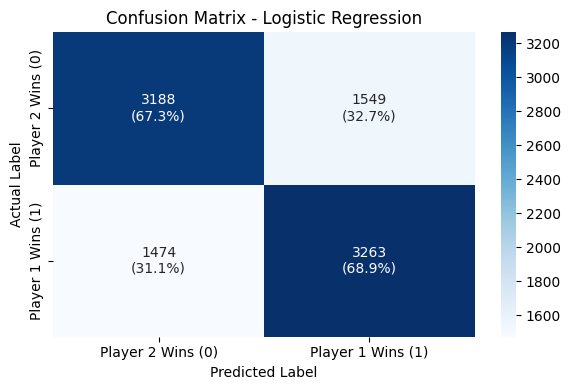

========== Random Forest ==========
Train Accuracy: 0.9938
Test Accuracy : 0.6527
Precision     : 0.6519
Recall        : 0.6555
F1 Score      : 0.6537
ROC-AUC       : 0.7141

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      4737
           1       0.65      0.66      0.65      4737

    accuracy                           0.65      9474
   macro avg       0.65      0.65      0.65      9474
weighted avg       0.65      0.65      0.65      9474


Confusion Matrix:

[[3079 1658]
 [1632 3105]]


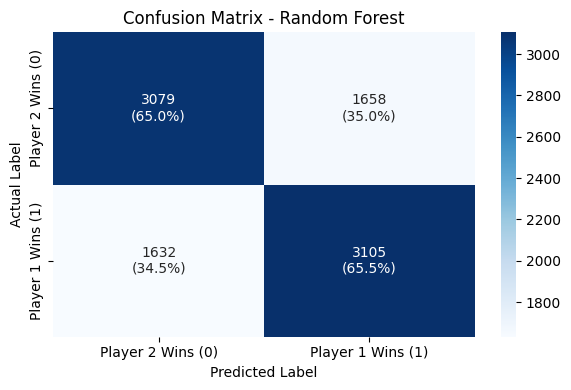

========== XGBoost ==========
Train Accuracy: 0.7047
Test Accuracy : 0.6804
Precision     : 0.6804
Recall        : 0.6804
F1 Score      : 0.6804
ROC-AUC       : 0.7526

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      4737
           1       0.68      0.68      0.68      4737

    accuracy                           0.68      9474
   macro avg       0.68      0.68      0.68      9474
weighted avg       0.68      0.68      0.68      9474


Confusion Matrix:

[[3223 1514]
 [1514 3223]]


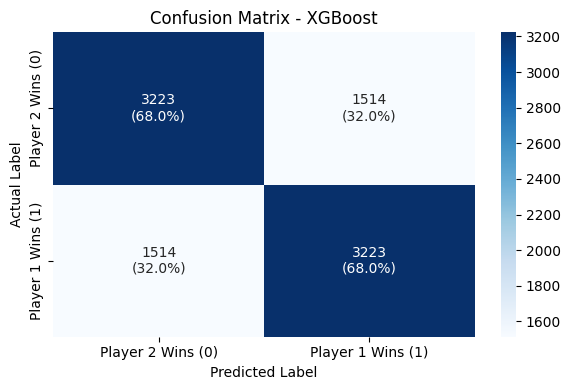

========== Neural Network ==========
Train Accuracy: 0.7033
Test Accuracy : 0.6699
Precision     : 0.6895
Recall        : 0.6183
F1 Score      : 0.652
ROC-AUC       : 0.7375

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.72      0.69      4737
           1       0.69      0.62      0.65      4737

    accuracy                           0.67      9474
   macro avg       0.67      0.67      0.67      9474
weighted avg       0.67      0.67      0.67      9474


Confusion Matrix:

[[3418 1319]
 [1808 2929]]


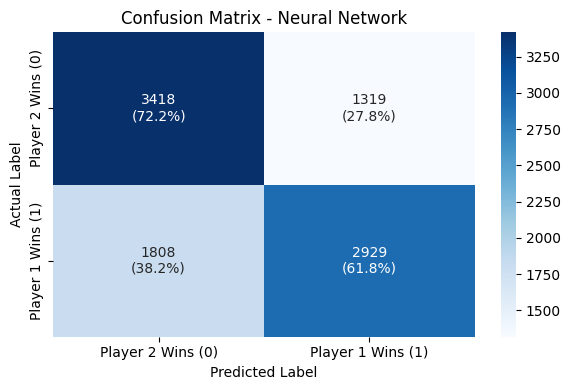

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.6809     0.6781  0.6888    0.6834   0.7538
1              XGBoost    0.6804     0.6804  0.6804    0.6804   0.7526
2       Neural Network    0.6699     0.6895  0.6183    0.6520   0.7375
3        Random Forest    0.6527     0.6519  0.6555    0.6537   0.7141


In [25]:
# =========================================================
# CONFUSION MATRIX PLOT FUNCTION
# =========================================================

def plot_confusion_matrix_with_percentages(y_true, y_pred, model_name, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    if labels is None:
        labels = ['Class 0', 'Class 1']

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j] * 100:.1f}%)"

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()


# =========================================================
# MODEL EVALUATION FUNCTION
# =========================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, labels=None):
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)
    
    print("====================================================")
    print(f"========== {model_name} ==========")
    print("====================================================")
    
    print("Train Accuracy:", round(train_acc, 4))
    print("Test Accuracy :", round(test_acc, 4))
    print("Precision     :", round(precision, 4))
    print("Recall        :", round(recall, 4))
    print("F1 Score      :", round(f1, 4))
    print("ROC-AUC       :", round(roc_auc, 4))
    
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_test_pred))
    
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_test_pred))
    
    plot_confusion_matrix_with_percentages(
        y_true=y_test,
        y_pred=y_test_pred,
        model_name=model_name,
        labels=labels
    )


# =========================================================
# CLASS LABELS
# =========================================================

class_labels = ['Player 2 Wins (0)', 'Player 1 Wins (1)']


# =========================================================
# EVALUATE ALL MODELS
# =========================================================

evaluate_model(log_model, X_train, X_test, y_train, y_test, 'Logistic Regression', labels=class_labels)
evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest', labels=class_labels)
evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost', labels=class_labels)
evaluate_model(nn_model, X_train, X_test, y_train, y_test, 'Neural Network', labels=class_labels)


# =========================================================
# MODEL COMPARISON TABLE
# =========================================================

results = []

models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Neural Network': nn_model
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print(results_df)

## Insights:
- Logistic Regression achieved the best overall baseline performance with the highest ROC-AUC (0.7538),
   highest F1-score (0.6834), and highest test accuracy (0.6809).
- XGBoost performed almost identically to Logistic Regression, with a ROC-AUC of 0.7526 and test accuracy of 0.6804, suggesting that the relationships in the data are not highly nonlinear.
- The similar performance between Logistic Regression and XGBoost indicates that the engineered features such as Rank_Diff, Pts_Diff, and Odd_Diff already capture most of the predictive signal effectively.
- Random Forest showed severe overfitting, with training accuracy of 99.38% but test accuracy of only 65.27%. This suggests that the baseline Random Forest model was too complex and memorized the training data.
- Despite very high training accuracy, Random Forest had the lowest ROC-AUC (0.7141), confirming that it generalized poorly to unseen future matches.
- The Neural Network achieved reasonable performance, but it did not outperform the simpler models. Although it had the highest precision (0.6895), its recall was relatively low (0.6183), meaning it missed more actual winning cases than the other models.
- Logistic Regression and XGBoost both produced balanced confusion matrices, indicating that they performed similarly across both classes without a strong prediction bias.
- Since the target classes are perfectly balanced, the similar values for precision, recall, F1-score, and accuracy suggest that the models are behaving consistently across both outcomes.
- Overall, Logistic Regression emerged as the strongest baseline model because it achieved the best balance between predictive performance, stability, and interpretability.
- XGBoost was a very close second and may improve further after hyperparameter tuning.

# Step 11 : Hyperparameter Tuning

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Logistic Regression Params:
{'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 0.01}
Best Logistic Regression CV Score:
0.7738170358842574
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Params:
{'clf__n_estimators': 500, 'clf__min_samples_split': 20, 'clf__min_samples_leaf': 2, 'clf__max_features': None, 'clf__max_depth': 5}
Best Random Forest CV Score:
0.7732440943336506
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Params:
{'clf__subsample': 0.8, 'clf__n_estimators': 500, 'clf__min_child_weight': 5, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}
Best XGBoost CV Score:
0.7735270454262999
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Neural Network Params:
{'clf__solver': 'adam', 'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (32,), 'clf__alpha': 0.1, 'clf__activation

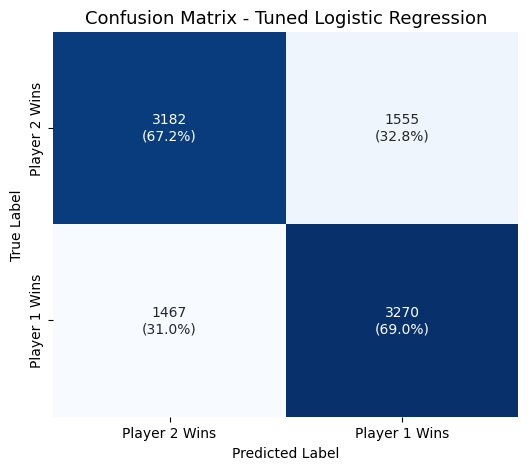


========== Tuned Random Forest ==========
Train Accuracy: 0.6962
Test Accuracy: 0.6809
Precision: 0.679
Recall: 0.6863
F1 Score: 0.6826
ROC-AUC: 0.754

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      4737
           1       0.68      0.69      0.68      4737

    accuracy                           0.68      9474
   macro avg       0.68      0.68      0.68      9474
weighted avg       0.68      0.68      0.68      9474


Confusion Matrix Values:

[[3200 1537]
 [1486 3251]]


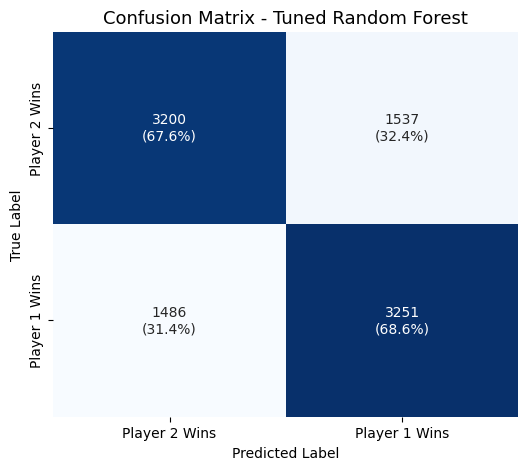


========== Tuned XGBoost ==========
Train Accuracy: 0.6952
Test Accuracy: 0.6804
Precision: 0.6772
Recall: 0.6895
F1 Score: 0.6833
ROC-AUC: 0.7546

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.67      0.68      4737
           1       0.68      0.69      0.68      4737

    accuracy                           0.68      9474
   macro avg       0.68      0.68      0.68      9474
weighted avg       0.68      0.68      0.68      9474


Confusion Matrix Values:

[[3180 1557]
 [1471 3266]]


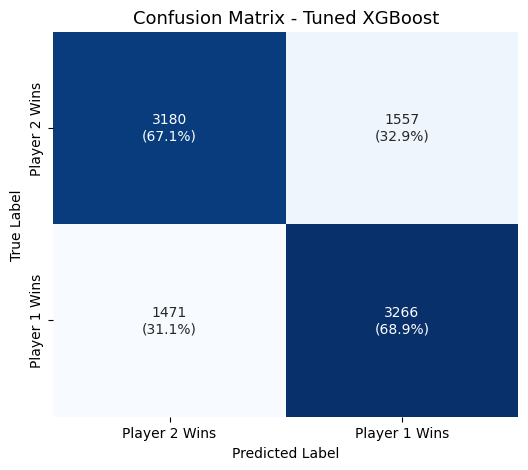


========== Tuned Neural Network ==========
Train Accuracy: 0.6937
Test Accuracy: 0.6809
Precision: 0.683
Recall: 0.6753
F1 Score: 0.6791
ROC-AUC: 0.7541

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.69      0.68      4737
           1       0.68      0.68      0.68      4737

    accuracy                           0.68      9474
   macro avg       0.68      0.68      0.68      9474
weighted avg       0.68      0.68      0.68      9474


Confusion Matrix Values:

[[3252 1485]
 [1538 3199]]


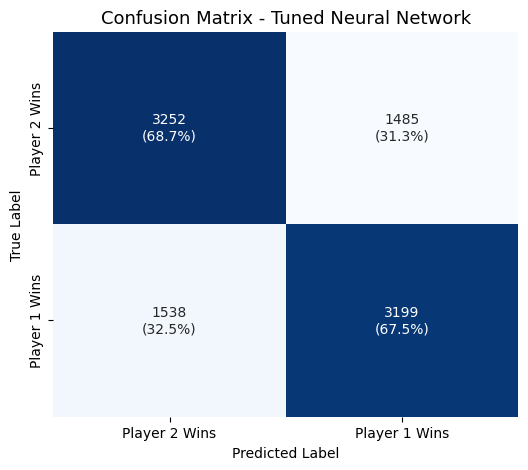

                       Model  Train Accuracy  Test Accuracy  Precision  \
0              Tuned XGBoost        0.695162       0.680388   0.677172   
1       Tuned Neural Network        0.693707       0.680916   0.682963   
2        Tuned Random Forest        0.696155       0.680916   0.678989   
3  Tuned Logistic Regression        0.695109       0.681022   0.677720   

     Recall  F1 Score   ROC-AUC  
0  0.689466  0.683264  0.754633  
1  0.675322  0.679121  0.754133  
2  0.686299  0.682625  0.753953  
3  0.690310  0.683957  0.753503  


In [26]:
# =========================================================
# HYPERPARAMETER TUNING + TRAIN TUNED MODELS + FINAL COMPARISON
# =========================================================

# =========================================================
# TIME-SERIES CROSS-VALIDATION
# =========================================================
tscv = TimeSeriesSplit(n_splits=5)

# =========================================================
# SCORING METRIC
# =========================================================
scoring_metric = 'roc_auc'

# =========================================================
# 1. LOGISTIC REGRESSION TUNING
# =========================================================
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(random_state=42, max_iter=2000))
])

log_param_dist = {
    'clf__C': [0.01, 0.1, 1, 10, 50, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']
}

log_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=log_param_dist,
    n_iter=12,
    cv=tscv,
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

log_search.fit(X_train, y_train)

print("Best Logistic Regression Params:")
print(log_search.best_params_)
print("Best Logistic Regression CV Score:")
print(log_search.best_score_)

best_log_model = log_search.best_estimator_

# =========================================================
# 2. RANDOM FOREST TUNING
# =========================================================
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [None, 5, 10, 15, 20, 30],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=tscv,
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Params:")
print(rf_search.best_params_)
print("Best Random Forest CV Score:")
print(rf_search.best_score_)

best_rf_model = rf_search.best_estimator_

# =========================================================
# 3. XGBOOST TUNING
# =========================================================
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'clf__max_depth': [3, 4, 5, 6, 8],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma': [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=tscv,
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Params:")
print(xgb_search.best_params_)
print("Best XGBoost CV Score:")
print(xgb_search.best_score_)

best_xgb_model = xgb_search.best_estimator_

# =========================================================
# 4. NEURAL NETWORK TUNING
# =========================================================
nn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(
        max_iter=500,
        random_state=42
    ))
])

nn_param_dist = {
    'clf__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64), (128, 64, 32)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01, 0.1],
    'clf__learning_rate_init': [0.0005, 0.001, 0.005, 0.01],
    'clf__solver': ['adam']
}

nn_search = RandomizedSearchCV(
    estimator=nn_pipeline,
    param_distributions=nn_param_dist,
    n_iter=15,
    cv=tscv,
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

nn_search.fit(X_train, y_train)

print("Best Neural Network Params:")
print(nn_search.best_params_)
print("Best Neural Network CV Score:")
print(nn_search.best_score_)

best_nn_model = nn_search.best_estimator_

# =========================================================
# CONFUSION MATRIX PLOT FUNCTION
# =========================================================
def plot_confusion_matrix_with_percentages(y_true, y_pred, model_name, labels=['Class 0', 'Class 1']):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j] * 100:.1f}%)"

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f'Confusion Matrix - {model_name}', fontsize=13)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# =========================================================
# EVALUATION FUNCTION FOR TUNED MODELS
# =========================================================
def evaluate_tuned_model(model, X_train, X_test, y_train, y_test, model_name):
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n========== {model_name} ==========")
    print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
    print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
    print("Precision:", round(precision_score(y_test, y_test_pred), 4))
    print("Recall:", round(recall_score(y_test, y_test_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_test_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
    
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_test_pred))
    
    print("\nConfusion Matrix Values:\n")
    print(confusion_matrix(y_test, y_test_pred))
    
    # Plot confusion matrix
    plot_confusion_matrix_with_percentages(
        y_true=y_test,
        y_pred=y_test_pred,
        model_name=model_name,
        labels=['Player 2 Wins', 'Player 1 Wins']
    )

# =========================================================
# EVALUATE ALL TUNED MODELS
# =========================================================
evaluate_tuned_model(best_log_model, X_train, X_test, y_train, y_test, 'Tuned Logistic Regression')
evaluate_tuned_model(best_rf_model, X_train, X_test, y_train, y_test, 'Tuned Random Forest')
evaluate_tuned_model(best_xgb_model, X_train, X_test, y_train, y_test, 'Tuned XGBoost')
evaluate_tuned_model(best_nn_model, X_train, X_test, y_train, y_test, 'Tuned Neural Network')

# =========================================================
# FINAL COMPARISON OF TUNED MODELS
# =========================================================
tuned_results = []

tuned_models = {
    'Tuned Logistic Regression': best_log_model,
    'Tuned Random Forest': best_rf_model,
    'Tuned XGBoost': best_xgb_model,
    'Tuned Neural Network': best_nn_model
}

for name, model in tuned_models.items():
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    tuned_results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc_score(y_test, y_test_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print(tuned_results_df)

## Insights:
- After hyperparameter tuning, all four models achieved very similar performance, with ROC-AUC values ranging between approximately 0.7535 and 0.7546.
- XGBoost achieved the highest ROC-AUC on the test set (0.7546), making it the strongest model in terms of ranking ability.
-  Logistic Regression achieved the highest test accuracy (0.6810), highest recall (0.6903), and highest F1-score (0.6840), showing that it remained extremely competitive even after tuning.
- Random Forest improved substantially after tuning. In the baseline model, it severely overfitted with train accuracy near 99%.After tuning, train accuracy dropped to 69.62% and test accuracy increased to 68.09%,indicating much better generalization.
- The tuned Random Forest model became far more stable because the selected parameters limited tree complexity through lower depth and larger minimum split sizes.
- The Neural Network also became more balanced after tuning. It achieved the second-highest ROC-AUC (0.7541) and showed more stable train-test performance.
- The very small differences between the tuned models suggest that the prediction problem is driven mainly by a few strong features rather than complex nonlinear interactions.
- The strong performance of Logistic Regression indicates that the relationship between the engineered variables and the target is relatively linear and well captured by simple models.
- The similarity between Logistic Regression and XGBoost suggests that features such as Rank_Diff, Pts_Diff, and Odd_Diff already summarize most of the predictive signal.
- The tuned models all achieved train accuracies close to 69% and test accuracies close to 68%, indicating that overfitting has been largely controlled across all models.
- The cross-validation ROC-AUC values were also very similar across all models, ranging from 0.7732 to 0.7738, which further supports the conclusion that no single model is dramatically superior to the others.
- Although XGBoost achieved the highest ROC-AUC, the difference was very small. Therefore, the final model choice should depend not only on predictive performance, but also on interpretability and ease of explanation.
- Overall, XGBoost can be selected as the final model because it achieved the highest ROC-AUC while still allowing feature importance extraction and maintaining stable generalization performance.

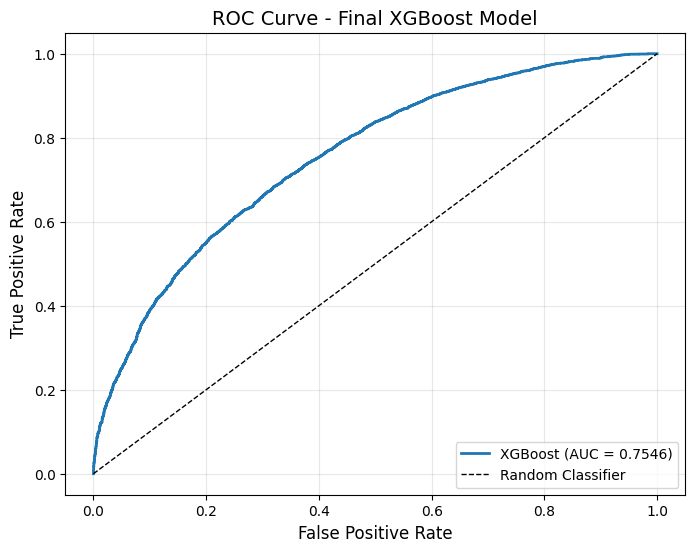

In [27]:
# =========================================================
# ROC CURVE FOR FINAL XGBOOST MODEL
# =========================================================
# Predicted probabilities
y_test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Final XGBoost Model', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Step 12 : Feature Importance

In [28]:
# =========================================================
# FEATURE IMPORTANCE FROM FINAL XGBOOST MODEL
# =========================================================

# Get feature names after preprocessing
feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance values
importance_values = best_xgb_model.named_steps['clf'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Show top 20 features
top_10_features = feature_importance_df.head(10)

print(top_10_features)

                          Feature  Importance
0                   num__Odd_Diff    0.598817
1                  num__Rank_Diff    0.038703
2          cat__Series_Grand Slam    0.021293
3            cat__Round_3rd Round    0.020240
4                   num__Pts_Diff    0.020158
5                  num__Is_Indoor    0.020128
6  cat__Series_International Gold    0.019818
7       cat__Series_International    0.019383
8        cat__Series_Masters 1000    0.018159
9             cat__Surface_Carpet    0.018013


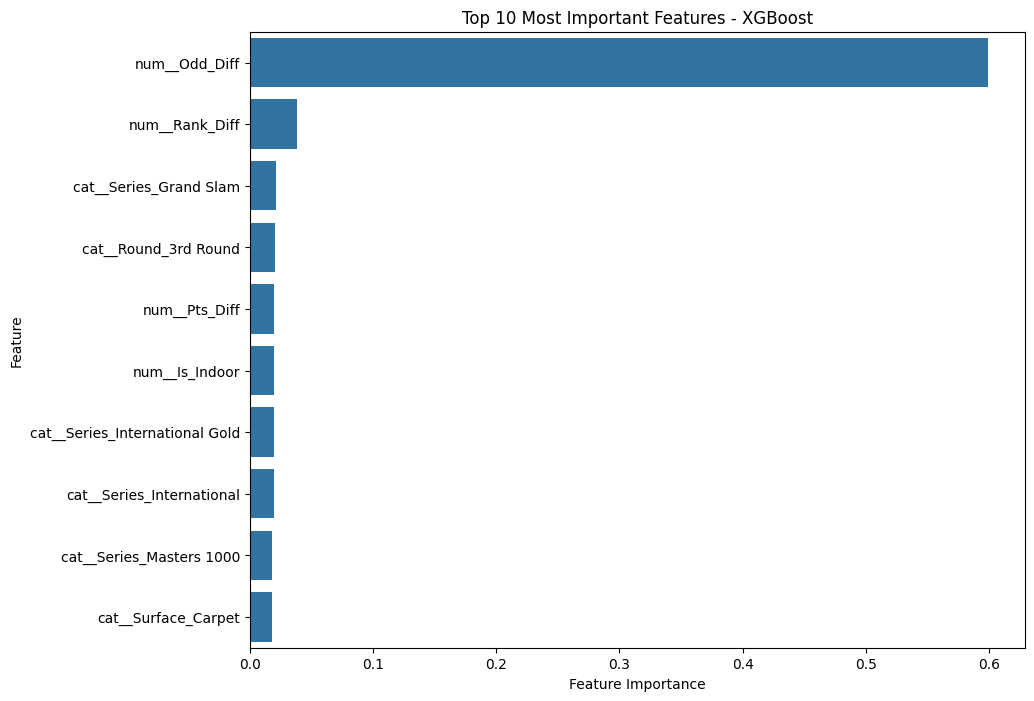

In [29]:
# =========================================================
# PLOT TOP 10 MOST IMPORTANT FEATURES
# =========================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features - XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

# Insights:
- Odd_Diff is by far the most important feature, contributing approximately 59.9% of the total feature importance. This indicates that the difference in betting odds between the two players is the strongest predictor of match outcome.
 - The dominance of Odd_Diff suggests that betting markets already incorporate a large amount of useful information, such as player ranking, recent form, injuries, surface suitability, and historical performance.
- Rank_Diff is the second most important feature, although its importance is much lower than Odd_Diff. This shows that ranking differences still matter, but much of their predictive value may already be reflected in betting odds.
- Tournament context variables such as Series_Grand Slam, Series_International Gold, Series_International, and Series_Masters 1000 also contribute to prediction performance.This suggests that match importance and tournament type influence player performance and competitiveness.
- Round_3rd Round appears as an important feature, indicating that the stage of the tournament can affect the likelihood of different match outcomes.
- Pts_Diff remains one of the important numerical variables, confirming that ATP points difference is a meaningful indicator of relative player quality.
- Is_Indoor contributes moderately, suggesting that indoor conditions affect player performance and therefore have predictive value.
- Surface_Carpet appears in the top 10 features despite being relatively rare in modern tennis, which may indicate that certain players perform very differently on less common surfaces.
- Overall, the feature importance results show that the model relies heavily on betting odds, while ranking, ATP points, tournament category, match round, and playing conditions provide additional predictive value.
- The heavy dominance of Odd_Diff also suggests that the prediction problem becomes substantially easier when betting market information is available.

# Step 13 : Saving the Model

In [30]:
# =========================================================
# SAVE FINAL DEPLOYMENT ARTIFACT FOR STREAMLIT
# =========================================================
# ---------------------------------------------------------
# SELECT FINAL MODEL
# ---------------------------------------------------------
# Change this only if you decide to deploy a different tuned model
best_final_model = best_xgb_model

# ---------------------------------------------------------
# CREATE ONE COMPLETE ARTIFACT
# ---------------------------------------------------------
tennis_app_artifact = {
    "model": best_final_model,
    "numerical_features": final_num_cols,
    "categorical_features": final_cat_cols,
    "all_features": final_num_cols + final_cat_cols,
    "target_name": target,
    "category_options": {
        "Surface": sorted(df["Surface"].dropna().unique().tolist()),
        "Series": sorted(df["Series"].dropna().unique().tolist()),
        "Round": sorted(df["Round"].dropna().unique().tolist())
    }
}

# ---------------------------------------------------------
# SAVE ARTIFACT
# ---------------------------------------------------------
joblib.dump(tennis_app_artifact, "tennis_app_artifact.pkl")

print("Saved successfully: tennis_app_artifact.pkl")

Saved successfully: tennis_app_artifact.pkl


In [31]:
# =========================================================
# TEST THE SAVED ARTIFACT
# =========================================================

# Load artifact
artifact = joblib.load("tennis_app_artifact.pkl")

# Extract model
loaded_model = artifact["model"]

# Create sample input
sample_input = pd.DataFrame([{
    "Rank_Diff": -10,
    "Pts_Diff": 250,
    "Odd_Diff": -0.40,
    "Is_Indoor": 1,
    "Surface": "Hard",
    "Series": "ATP250",
    "Round": "Quarterfinals"
}])

# Reorder columns exactly as used in training
sample_input = sample_input[artifact["all_features"]]

# Predict
pred_class = loaded_model.predict(sample_input)[0]
pred_prob = loaded_model.predict_proba(sample_input)[0, 1]

print("Predicted Class:", pred_class)
print("Probability of Player 1 Winning:", round(pred_prob, 4))
print("Probability of Player 2 Winning:", round(1 - pred_prob, 4))

Predicted Class: 0
Probability of Player 1 Winning: 0.4256
Probability of Player 2 Winning: 0.5744
